# Experiment Analysis & Turn-On Curve Diagnostics
This notebook aggregates all trained neural network results from the `experiments/` directory. It parses the metadata (`config.json`) and the computed physics numbers (`metrics.json`) to create comparative summaries and publication-ready plots for the final report.


In [1]:
import os
import glob
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# IF YOU WANT TO RUN WITH SEPEARTE SEEDS INSTEAF OF AVERAGE, CTRL+F THIS: "ChangeHereForSeed" AND CHANGE ALL NEEDED PLACES>.

EXPERIMENTS_DIR = r"experiments/config batch 6 - simple stuff - fixed model weights to have validation"

# Apply professional plotting styles for the report
plt.rcParams.update({
    'font.size': 12,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'legend.fontsize': 11,
    'figure.facecolor': 'white',
    'grid.linestyle': ':',
    'grid.alpha': 0.6
})

def load_all_experiments(base_dir="experiments"):
    """Crawls the experiments directory and collects configuration and evaluation metrics."""
    summary_data = []
    
    # Locate all subdirectories containing a metrics file
    # metrics_files = glob.glob(os.path.join(base_dir, "run_*", "metrics.json")) # ChangeHereForSeed use this instead of line after
    metrics_files = glob.glob(os.path.join(base_dir, "run_*", "metrics_averaged.json"))
    print(len(metrics_files))
    for m_path in metrics_files:
        run_dir = os.path.dirname(m_path)
        c_path = os.path.join(run_dir, "config.json")
        
        with open(m_path, 'r') as f:
            metrics = json.load(f)
        with open(c_path, 'r') as f:
            config = json.load(f)
            
        # Dynamically create the architecture string (e.g., [32, 16] becomes "32x16")
        hidden_layers = config.get("hidden_layers", [])
        architecture = "x".join(map(str, hidden_layers)) if hidden_layers else "Baseline"
            
        # Compile flat dictionary of parameters and primary metrics directly from JSON
        run_summary = {
            "run_id": os.path.basename(run_dir),
            "experiment_name": config.get("experiment_name"),
            "features": ", ".join(config.get("features_to_use", [])),
            # "learning_rate": config.get("learning_rate"),
            "learning_rate": config.get("learning_rate"),
            "batch_size": config.get("batch_size"),
            "architecture": architecture,
            "epochs": config.get("epochs"),
            "eff_at_0.5_FR": metrics["global_efficiency"].get("0.5%"),
            "eff_at_1.0_FR": metrics["global_efficiency"].get("1.0%"),
            "fd_midpoint": metrics["turn_on_curve"]["fermi_dirac_fit"].get("midpoint"),
            "fd_slope": metrics["turn_on_curve"]["fermi_dirac_fit"].get("slope"),
            "fd_plateau": metrics["turn_on_curve"]["fermi_dirac_fit"].get("plateau"),
            "fd_chi2_red": metrics["turn_on_curve"]["fermi_dirac_fit"].get("chi2_red"),
            "fd_p_value": metrics["turn_on_curve"]["fermi_dirac_fit"].get("p_value"),
            "path": run_dir,
            "seed": config.get("seed", 0)
        }
        summary_data.append(run_summary)
        
    return pd.DataFrame(summary_data)

# Load and display the master experiment table
df_experiments = load_all_experiments(base_dir=EXPERIMENTS_DIR)
df_experiments = df_experiments.drop('seed', axis=1).drop_duplicates(subset='experiment_name')
df_experiments.sort_values(by="eff_at_0.5_FR", ascending=False)

7


,run_id,experiment_name,features,learning_rate,batch_size,architecture,epochs,eff_at_0.5_FR,eff_at_1.0_FR,fd_midpoint,fd_slope,fd_plateau,fd_chi2_red,fd_p_value,path
3,run_TauNet_lr0.001_bs256_arch32x16_em2_3x3_dom...,TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominan...,"em2_3x3_dominance, em2_3x3_maxdist, tob_pt_only",0.001,256.0,32x16,20,0.194792,0.217186,30.409833,0.262907,0.954471,48.449487,0.000000e+00,experiments/config batch 6 - simple stuff - fi...
6,run_0_baseline_tob_pt,Baseline_tob_pt,tob_pt,0.000,NaN,Baseline,0,0.186787,1.000000,33.037571,0.255719,1.000000,49.567916,0.000000e+00,experiments/config batch 6 - simple stuff - fi...
0,run_TauNet_lr0.001_bs256_arch32x16_em2_3x3_dom...,TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominan...,"em2_3x3_dominance, em2_3x3_maxdist",0.001,256.0,32x16,20,0.156644,0.170430,34.066707,0.087495,0.722145,5.247771,1.780357e-25,experiments/config batch 6 - simple stuff - fi...


## Performance Summary Table
Below is the master compilation of all execution parameters alongside hard numerical results. We evaluate global signal efficiencies at tightly constrained background Fake Rates ($0.5\%$ and $1.0\%$), alongside the extracted Fermi-Dirac fit parameters for the 1D turn-on curves.

In [2]:
# Display select columns for clean reporting 
# ChangeHereForSeed use the commented out line instead
# view_cols = ['experiment_name', 'seed', 'eff_at_0.5_FR', 'fd_midpoint', 'fd_slope', 'fd_plateau', 'fd_chi2_red', 'fd_p_value', 'learning_rate', 'batch_size', 'architecture', 'features', 'epochs']

view_cols = ['experiment_name', 'eff_at_0.5_FR', 'fd_midpoint', 'fd_slope', 'fd_plateau', 'fd_chi2_red', 'fd_p_value', 'learning_rate', 'batch_size', 'architecture', 'features', 'epochs']

temp_df = df_experiments[view_cols].copy()

# Export strictly the numbers/parameters without the cluttered experiment name
# temp_df.drop(columns=['experiment_name']).to_csv('exp_results_table.csv', index=False)
temp_df.to_csv('exp_results_table.csv', index=False)

print(len(temp_df))
df_experiments[view_cols].style.background_gradient(subset=['eff_at_0.5_FR', 'fd_plateau'], cmap='viridis')

3


,experiment_name,eff_at_0.5_FR,fd_midpoint,fd_slope,fd_plateau,fd_chi2_red,fd_p_value,learning_rate,batch_size,architecture,features,epochs
0,TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist,0.156644,34.066707,0.087495,0.722145,5.247771,0.000000,0.001000,256.000000,32x16,"em2_3x3_dominance, em2_3x3_maxdist",20
3,TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only,0.194792,30.409833,0.262907,0.954471,48.449487,0.000000,0.001000,256.000000,32x16,"em2_3x3_dominance, em2_3x3_maxdist, tob_pt_only",20
6,Baseline_tob_pt,0.186787,33.037571,0.255719,1.000000,49.567916,0.000000,0.000000,nan,Baseline,tob_pt,0


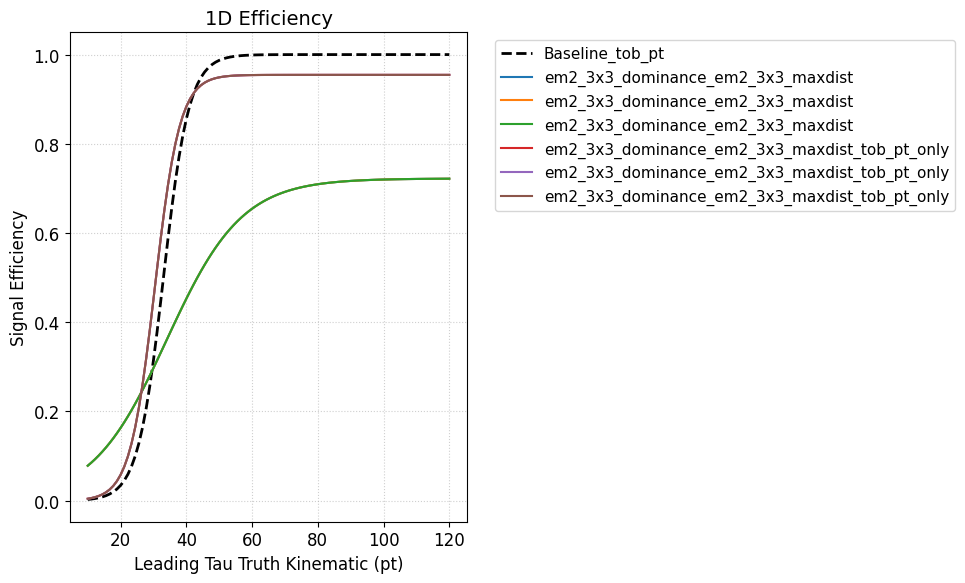

In [5]:
import numpy as np
import matplotlib.pyplot as plt

def fermi_dirac(x, midpoint, slope, plateau):
    return plateau / (1.0 + np.exp(-slope * (x - midpoint)))

x_vals = np.linspace(10, 120, 100)

base_features = [
    'em2_max1', 'em2_max2', 'em2_maxdist', 'em2_width',
    'frach_approx', 'em2_maxratio_approx', 'em2_3x3_max2',
    'em2_3x3_maxratio_approx', 'em2_3x3_maxdist'
]

def plot_experiments(name, experiment_names, title):
    plt.figure(figsize=(10, 6))
    
    baseline = df_experiments[df_experiments['experiment_name'] == 'Baseline_tob_pt']
    if not baseline.empty:
        b_row = baseline.iloc[0]
        y_vals = fermi_dirac(x_vals, b_row['fd_midpoint'], b_row['fd_slope'], b_row['fd_plateau'])
        plt.plot(x_vals, y_vals, label='Baseline_tob_pt', linestyle='--', color='black', linewidth=2)

    for exp in experiment_names:
        row = df_experiments[df_experiments['experiment_name'] == exp]
        if not row.empty:
            r = row.iloc[0]
            y_vals = fermi_dirac(x_vals, r['fd_midpoint'], r['fd_slope'], r['fd_plateau'])
            clean_label = exp.replace('TauNet_lr0.001_bs256_arch32x16_', '')
            plt.plot(x_vals, y_vals, label=clean_label)
    
    plt.title(title)
    plt.xlabel('Leading Tau Truth Kinematic (pt)')
    plt.ylabel('Signal Efficiency')
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(name + '.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# g1_names = [f'TauNet_lr0.001_bs256_arch32x16_{f}' for f in base_features]
# plot_experiments("Each new feature by itself - CLEAN", g1_names, '1D Efficiency: Individual Features')

# g2_names = [f'TauNet_lr0.001_bs256_arch32x16_{f}_5layers3features' for f in base_features]
# plot_experiments("New feature + 5layers3features - CLEAN", g2_names, '1D Efficiency: Features + 5layers3features')

# g3_names = [f'TauNet_lr0.001_bs256_arch32x16_{f}_core_physics' for f in base_features]
# plot_experiments("New feature + core physics - CLEAN", g3_names, '1D Efficiency: Features + core_physics')

# g4_names = [f'TauNet_lr0.001_bs256_arch32x16_{f}_core_physics_5layers3features' for f in base_features]
# plot_experiments("New feature + core physics + 5layers3features - CLEAN", g4_names, '1D Efficiency: Features + core_physics + 5layers3features')

# combined_base = 'em2_max1_em2_max2_em2_maxdist_em2_width_frach_approx_em2_maxratio_approx_em2_3x3_max2_em2_3x3_maxratio_approx_em2_3x3_maxdist'
# g5_names = [
#     f'TauNet_lr0.001_bs256_arch32x16_{combined_base}',
#     f'TauNet_lr0.001_bs256_arch32x16_{combined_base}_core_physics',
#     f'TauNet_lr0.001_bs256_arch32x16_{combined_base}_5layers3features',
#     f'TauNet_lr0.001_bs256_arch32x16_{combined_base}_core_physics_5layers3features'
# ]
# plot_experiments("Total comparisons - CLEAN", g5_names, '1D Efficiency: Combined Features Variations')

g_names = [
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only",
]
plot_experiments("1", g_names, '1D Efficiency')


## 1D Turn-On Curve Comparison
The cell below plots the binned efficiencies calculated at a $0.5\%$ target background Fake Rate, overlaying the analytical Fermi-Dirac fit curves for each distinct experimental run.

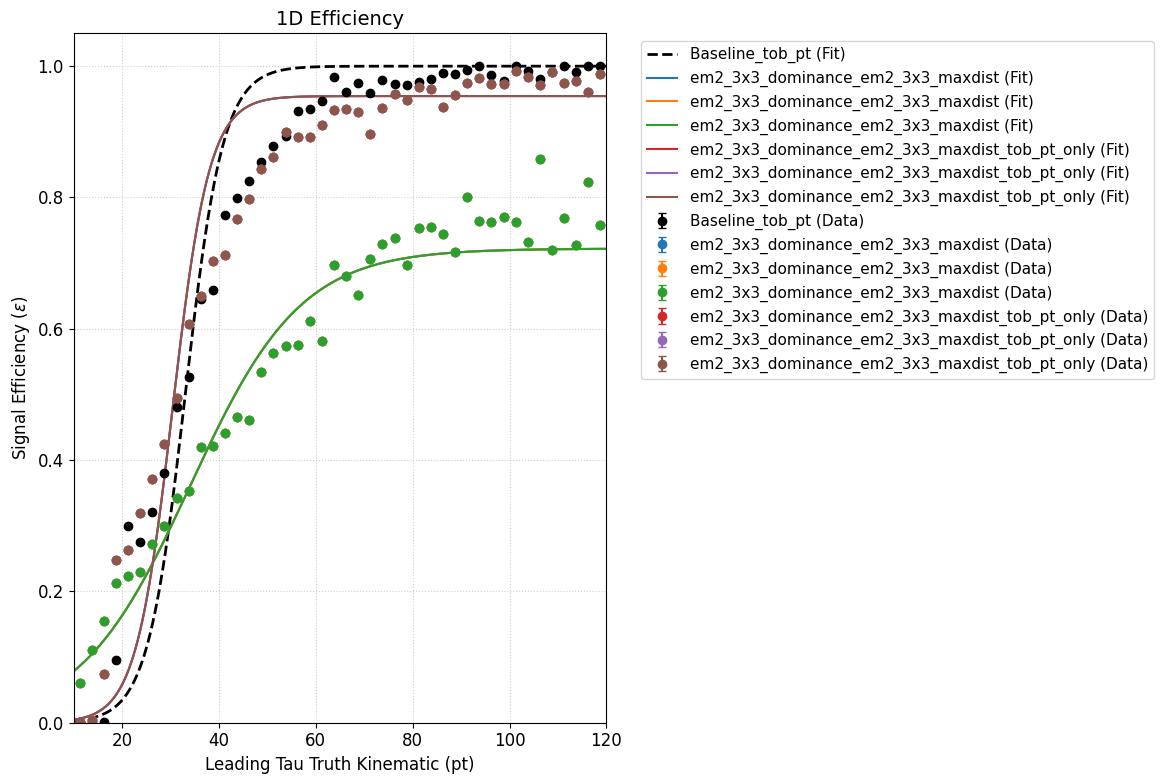

In [6]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

def fermi_dirac(x, midpoint, slope, plateau):
    # Added np.clip to avoid overflow warnings as seen in your second cell
    return plateau / (1.0 + np.exp(-np.clip(slope * (x - midpoint), -500, 500)))

# Increased resolution for smoother curve rendering
x_vals = np.linspace(10, 120, 500)

base_features = [
    'em2_max1', 'em2_max2', 'em2_maxdist', 'em2_width',
    'frach_approx', 'em2_maxratio_approx', 'em2_3x3_max2',
    'em2_3x3_maxratio_approx', 'em2_3x3_maxdist'
]

def plot_experiments(name, experiment_names, title):
    plt.figure(figsize=(12, 8)) # Increased size to fit legends and data nicely
    
    # Plot Baseline
    baseline = df_experiments[df_experiments['experiment_name'] == 'Baseline_tob_pt']
    if not baseline.empty:
        b_row = baseline.iloc[0]
        
        # Load JSON for baseline points
        m_path = os.path.join(b_row['path'], "metrics.json")
        with open(m_path, 'r') as f:
            metrics = json.load(f)
            
        toc_data = metrics["turn_on_curve"]
        eval_bins = np.array(toc_data.get("bins", toc_data.get("pt_bins")))
        bin_centers = (eval_bins[:-1] + eval_bins[1:]) / 2.0
        binned_effs = toc_data["binned_efficiencies"]
        binned_errs = toc_data.get("binned_errors", np.zeros_like(binned_effs))
        
        # Plot Baseline Data Points
        plt.errorbar(bin_centers, binned_effs, yerr=binned_errs, fmt='o', 
                     capsize=3, color='black', label='Baseline_tob_pt (Data)')
        
        # Plot Baseline Fit
        y_vals = fermi_dirac(x_vals, b_row['fd_midpoint'], b_row['fd_slope'], b_row['fd_plateau'])
        plt.plot(x_vals, y_vals, label='Baseline_tob_pt (Fit)', linestyle='--', color='black', linewidth=2)

    # Plot specific experiments
    for exp in experiment_names:
        row = df_experiments[df_experiments['experiment_name'] == exp]
        if not row.empty:
            r = row.iloc[0]
            
            # Load JSON for experiment points
            m_path = os.path.join(r['path'], "metrics.json")
            with open(m_path, 'r') as f:
                metrics = json.load(f)
                
            toc_data = metrics["turn_on_curve"]
            eval_bins = np.array(toc_data.get("bins", toc_data.get("pt_bins")))
            bin_centers = (eval_bins[:-1] + eval_bins[1:]) / 2.0
            binned_effs = toc_data["binned_efficiencies"]
            binned_errs = toc_data.get("binned_errors", np.zeros_like(binned_effs))
            
            clean_label = exp.replace('TauNet_lr0.001_bs256_arch32x16_', '')
            
            # Plot Experiment Data Points
            line = plt.errorbar(bin_centers, binned_effs, yerr=binned_errs, fmt='o', 
                                capsize=3, label=f"{clean_label} (Data)")
            
            # Plot Experiment Fit (using the same color as the scatter points)
            y_vals = fermi_dirac(x_vals, r['fd_midpoint'], r['fd_slope'], r['fd_plateau'])
            plt.plot(x_vals, y_vals, label=f"{clean_label} (Fit)", color=line[0].get_color())
    
    plt.title(title)
    plt.xlabel('Leading Tau Truth Kinematic (pt)')
    plt.ylabel(r'Signal Efficiency ($\epsilon$)')
    plt.xlim(10, 120)
    plt.ylim(0.0, 1.05)
    
    # Position the legend outside the plot so it doesn't overlap the curves
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(name + '.pdf', format='pdf', bbox_inches='tight')
    plt.show()

# -----------------
# Generate Plots
# -----------------
# g1_names = [f'TauNet_lr0.001_bs256_arch32x16_{f}' for f in base_features]
# plot_experiments("Each new feature by itself", g1_names, '1D Efficiency: Individual Features')

# g2_names = [f'TauNet_lr0.001_bs256_arch32x16_{f}_5layers3features' for f in base_features]
# plot_experiments("New feature + 5layers3features", g2_names, '1D Efficiency: Features + 5layers3features')

# g3_names = [f'TauNet_lr0.001_bs256_arch32x16_{f}_core_physics' for f in base_features]
# plot_experiments("New feature + core physics", g3_names, '1D Efficiency: Features + core_physics')

# g4_names = [f'TauNet_lr0.001_bs256_arch32x16_{f}_core_physics_5layers3features' for f in base_features]
# plot_experiments("New feature + core physics + 5layers3features", g4_names, '1D Efficiency: Features + core_physics + 5layers3features')

# combined_base = 'em2_max1_em2_max2_em2_maxdist_em2_width_frach_approx_em2_maxratio_approx_em2_3x3_max2_em2_3x3_maxratio_approx_em2_3x3_maxdist'
# g5_names = [
#     f'TauNet_lr0.001_bs256_arch32x16_{combined_base}',
#     f'TauNet_lr0.001_bs256_arch32x16_{combined_base}_core_physics',
#     f'TauNet_lr0.001_bs256_arch32x16_{combined_base}_5layers3features',
#     f'TauNet_lr0.001_bs256_arch32x16_{combined_base}_core_physics_5layers3features'
# ]
# plot_experiments("Total comparisons", g5_names, '1D Efficiency: Combined Features Variations')

g_names = [
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only",
]
plot_experiments("1", g_names, '1D Efficiency')

In [ ]:
# HEAT MAP PRETTY PRINT FOR LATEX


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create a clean mapping for your experiment names
# We group them into: Single Layers, Single Features, and the Combined model
name_mapping = {
# Baseline
"Baseline_tob_pt": "Baseline TOB PT",

# Individual Features
"TauNet_lr0.001_bs256_arch32x16_em2_max1": "EM2 Max",
"TauNet_lr0.001_bs256_arch32x16_em2_max2": "EM2 2nd Max",
"TauNet_lr0.001_bs256_arch32x16_em2_maxdist": "EM2 MaxDist",
"TauNet_lr0.001_bs256_arch32x16_em2_width": "EM2 Width",
"TauNet_lr0.001_bs256_arch32x16_frach_approx": "FracH Approx",
"TauNet_lr0.001_bs256_arch32x16_em2_maxratio_approx": "EM2 MaxRatio Approx",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_max2": "EM2 3x3 Max2",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxratio_approx": "EM2 3x3 MaxRatio Approx",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist": "EM2 3x3 MaxDist",

# Features + 5 Layers 3 Features
"TauNet_lr0.001_bs256_arch32x16_em2_max1_5layers3features": "EM2 Max1 + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_max2_5layers3features": "EM2 Max2 + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_maxdist_5layers3features": "EM2 MaxDist + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_width_5layers3features": "EM2 Width + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_frach_approx_5layers3features": "FracH Approx + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_maxratio_approx_5layers3features": "EM2 MaxRatio Approx + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_max2_5layers3features": "EM2 3x3 Max2 + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxratio_approx_5layers3features": "EM2 3x3 MaxRatio Approx + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist_5layers3features": "EM2 3x3 MaxDist + 5 Layers 3 Features",

# Features + Core Physics
"TauNet_lr0.001_bs256_arch32x16_em2_max1_core_physics": "EM2 Max1 + Core Physics",
"TauNet_lr0.001_bs256_arch32x16_em2_max2_core_physics": "EM2 Max2 + Core Physics",
"TauNet_lr0.001_bs256_arch32x16_em2_maxdist_core_physics": "EM2 MaxDist + Core Physics",
"TauNet_lr0.001_bs256_arch32x16_em2_width_core_physics": "EM2 Width + Core Physics",
"TauNet_lr0.001_bs256_arch32x16_frach_approx_core_physics": "FracH Approx + Core Physics",
"TauNet_lr0.001_bs256_arch32x16_em2_maxratio_approx_core_physics": "EM2 MaxRatio Approx + Core Physics",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_max2_core_physics": "EM2 3x3 Max2 + Core Physics",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxratio_approx_core_physics": "EM2 3x3 MaxRatio Approx + Core Physics",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist_core_physics": "EM2 3x3 MaxDist + Core Physics",

# Features + Core Physics + 5 Layers 3 Features
"TauNet_lr0.001_bs256_arch32x16_em2_max1_core_physics_5layers3features": "EM2 Max1 + Core Physics + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_max2_core_physics_5layers3features": "EM2 Max2 + Core Physics + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_maxdist_core_physics_5layers3features": "EM2 MaxDist + Core Physics + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_width_core_physics_5layers3features": "EM2 Width + Core Physics + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_frach_approx_core_physics_5layers3features": "FracH Approx + Core Physics + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_maxratio_approx_core_physics_5layers3features": "EM2 MaxRatio Approx + Core Physics + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_max2_core_physics_5layers3features": "EM2 3x3 Max2 + Core Physics + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxratio_approx_core_physics_5layers3features": "EM2 3x3 MaxRatio Approx + Core Physics + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist_core_physics_5layers3features": "EM2 3x3 MaxDist + Core Physics + 5 Layers 3 Features",

# Combined Features Variations
"TauNet_lr0.001_bs256_arch32x16_em2_max1_em2_max2_em2_maxdist_em2_width_frach_approx_em2_maxratio_approx_em2_3x3_max2_em2_3x3_maxratio_approx_em2_3x3_maxdist": "Combined Features",
"TauNet_lr0.001_bs256_arch32x16_em2_max1_em2_max2_em2_maxdist_em2_width_frach_approx_em2_maxratio_approx_em2_3x3_max2_em2_3x3_maxratio_approx_em2_3x3_maxdist_5layers3features": "Combined Features + 5 Layers 3 Features",
"TauNet_lr0.001_bs256_arch32x16_em2_max1_em2_max2_em2_maxdist_em2_width_frach_approx_em2_maxratio_approx_em2_3x3_max2_em2_3x3_maxratio_approx_em2_3x3_maxdist_core_physics": "Combined Features + Core Physics",
"TauNet_lr0.001_bs256_arch32x16_em2_max1_em2_max2_em2_maxdist_em2_width_frach_approx_em2_maxratio_approx_em2_3x3_max2_em2_3x3_maxratio_approx_em2_3x3_maxdist_core_physics_5layers3features": "Combined Features + Core Physics + 5 Layers 3 Features"
}

# Apply mapping and set as index
df_heat = df_experiments.copy()
df_heat['Clean_Name'] = df_heat['experiment_name'].map(name_mapping)

# Drop any rows that didn't match the map (optional) and set index
df_heat = df_heat.dropna(subset=['Clean_Name']).set_index('Clean_Name')

# Define the order we want them to appear in the heatmap (top to bottom)
ordered_index = [
"Baseline TOB PT",
"EM2 Max",
"EM2 2nd Max",
"EM2 MaxDist",
# "EM2 Width",
"FracH Approx",
"EM2 MaxRatio Approx",
"EM2 3x3 Max2",
"EM2 3x3 MaxRatio Approx",
"EM2 3x3 MaxDist",
"EM2 Max1 + 5 Layers 3 Features",
"EM2 Max2 + 5 Layers 3 Features",
"EM2 MaxDist + 5 Layers 3 Features",
# "EM2 Width + 5 Layers 3 Features",
"FracH Approx + 5 Layers 3 Features",
"EM2 MaxRatio Approx + 5 Layers 3 Features",
"EM2 3x3 Max2 + 5 Layers 3 Features",
"EM2 3x3 MaxRatio Approx + 5 Layers 3 Features",
"EM2 3x3 MaxDist + 5 Layers 3 Features",
"EM2 Max1 + Core Physics",
"EM2 Max2 + Core Physics",
"EM2 MaxDist + Core Physics",
# "EM2 Width + Core Physics",
"FracH Approx + Core Physics",
"EM2 MaxRatio Approx + Core Physics",
"EM2 3x3 Max2 + Core Physics",
"EM2 3x3 MaxRatio Approx + Core Physics",
"EM2 3x3 MaxDist + Core Physics",
"EM2 Max1 + Core Physics + 5 Layers 3 Features",
"EM2 Max2 + Core Physics + 5 Layers 3 Features",
"EM2 MaxDist + Core Physics + 5 Layers 3 Features",
# "EM2 Width + Core Physics + 5 Layers 3 Features",
"FracH Approx + Core Physics + 5 Layers 3 Features",
"EM2 MaxRatio Approx + Core Physics + 5 Layers 3 Features",
"EM2 3x3 Max2 + Core Physics + 5 Layers 3 Features",
"EM2 3x3 MaxRatio Approx + Core Physics + 5 Layers 3 Features",
"EM2 3x3 MaxDist + Core Physics + 5 Layers 3 Features",
"Combined Features",
"Combined Features + 5 Layers 3 Features",
"Combined Features + Core Physics",
"Combined Features + Core Physics + 5 Layers 3 Features"

]
df_heat = df_heat.reindex(ordered_index)

# 2. Plotting the 1x3 Heatmap
fig, axes = plt.subplots(1, 3, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1, 1]})

# Midpoint Heatmap (Lower is better, so we reverse the colormap: _r)
sns.heatmap(df_heat[['fd_midpoint']], annot=True, fmt=".2f", cmap="Greens_r", 
            ax=axes[0], cbar=False, linewidths=0.5, linecolor='white')
axes[0].set_title("Midpoint\n(Lower is Better)", pad=10, weight='bold')
axes[0].set_ylabel("") 

# Slope Heatmap (Higher is better)
sns.heatmap(df_heat[['fd_slope']], annot=True, fmt=".4f", cmap="Blues", 
            ax=axes[1], cbar=False, linewidths=0.5, linecolor='white')
axes[1].set_title("Slope\n(Higher is Better)", pad=10, weight='bold')
axes[1].set_ylabel("")
axes[1].set_yticks([]) # Hide y-axis labels for the middle plot so it's not cluttered

# Plateau Heatmap (Higher is better)
sns.heatmap(df_heat[['fd_plateau']], annot=True, fmt=".4f", cmap="Oranges", 
            ax=axes[2], cbar=False, linewidths=0.5, linecolor='white')
axes[2].set_title("Plateau\n(Higher is Better)", pad=10, weight='bold')
axes[2].set_ylabel("")
axes[2].set_yticks([]) # Hide y-axis labels for the right plot

# Adjust layout and save
fig.tight_layout()
fig.savefig('DESCRIBE HEATMAP HERE.pdf', format='pdf', bbox_inches='tight')
plt.show()

# DIFFERENT NEURAL NETWORKS ANALYSIS

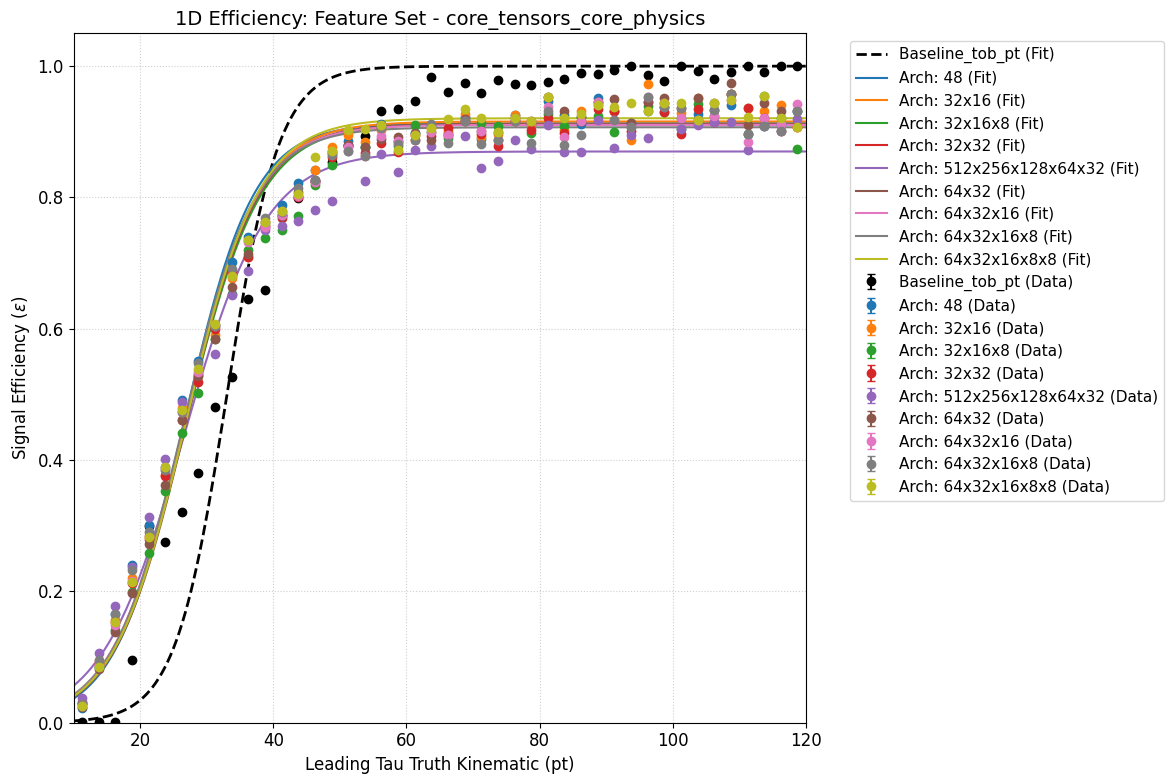

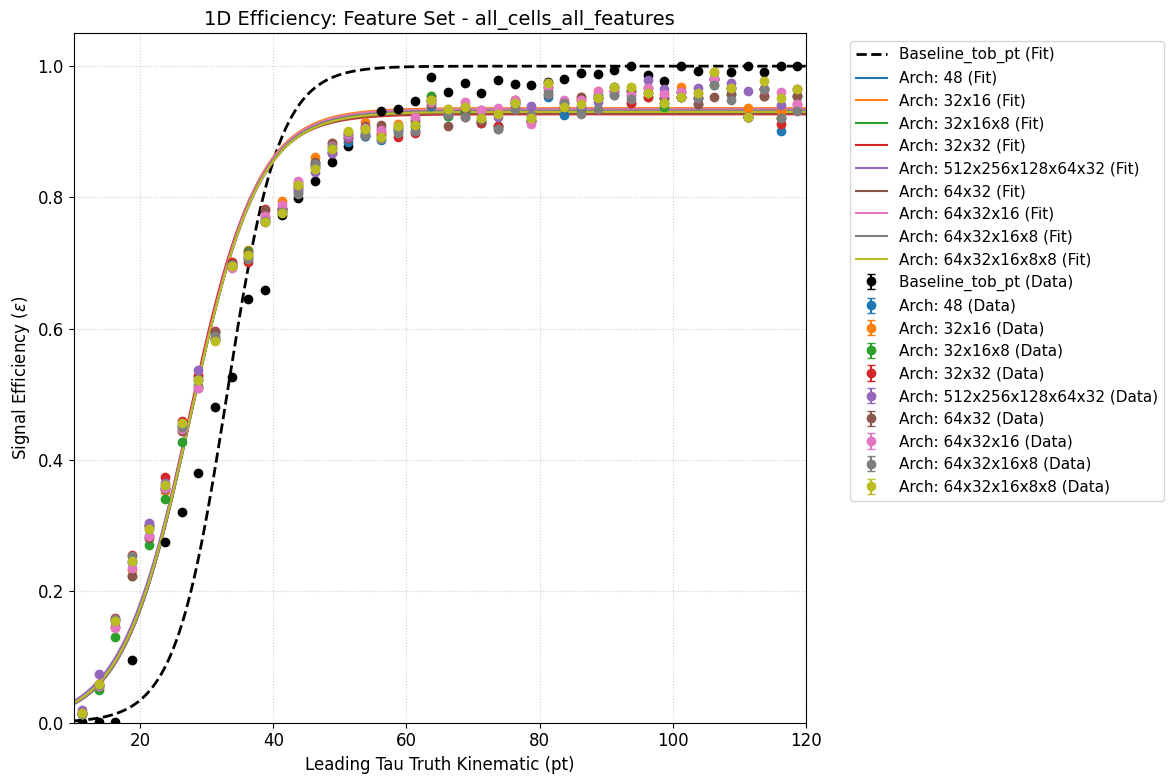

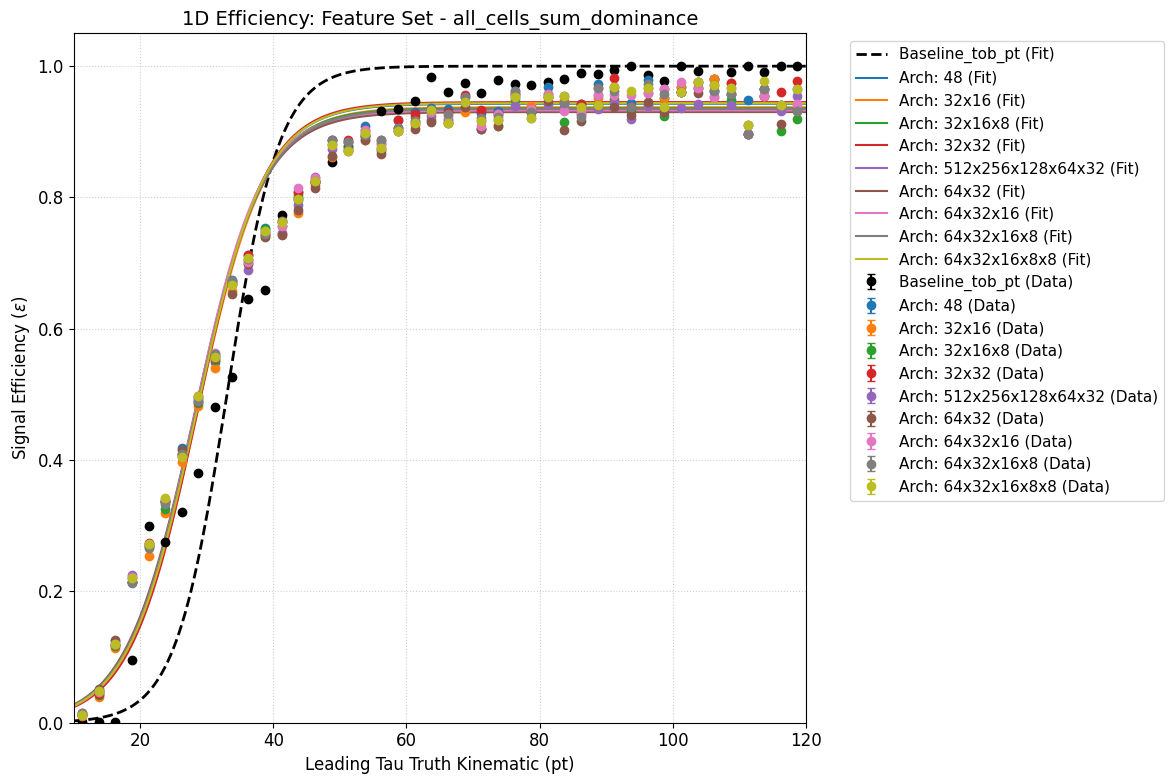

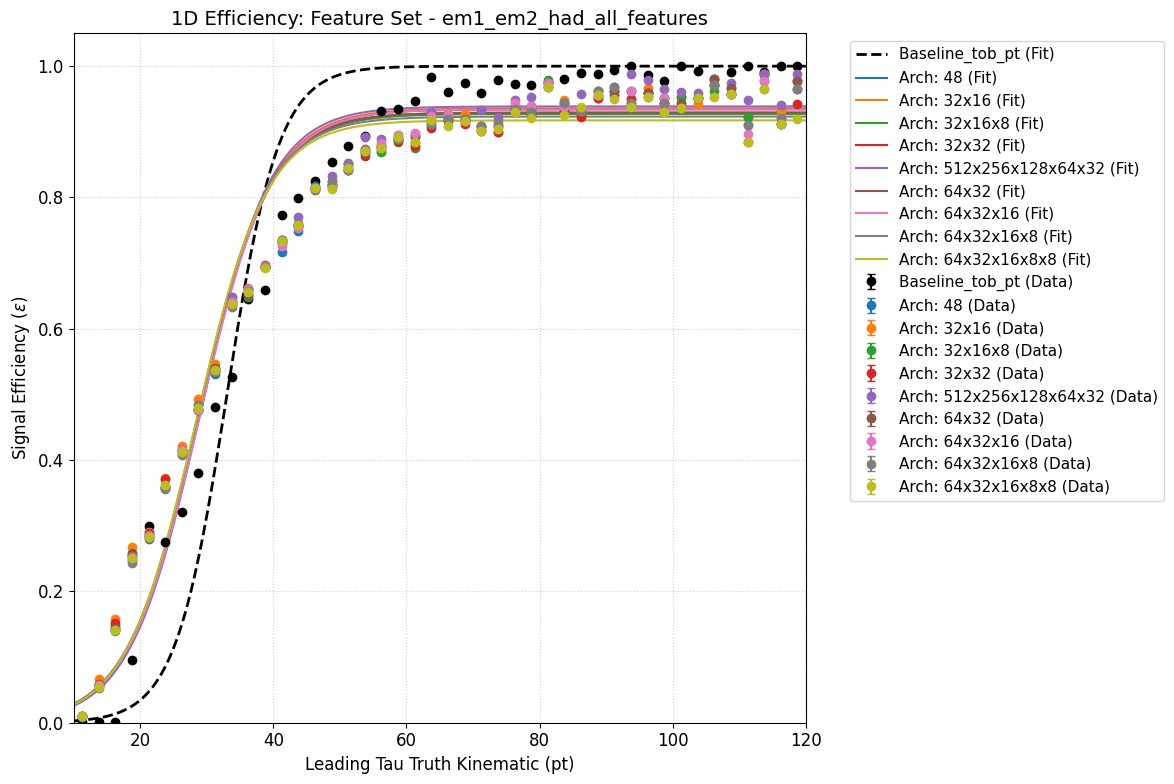

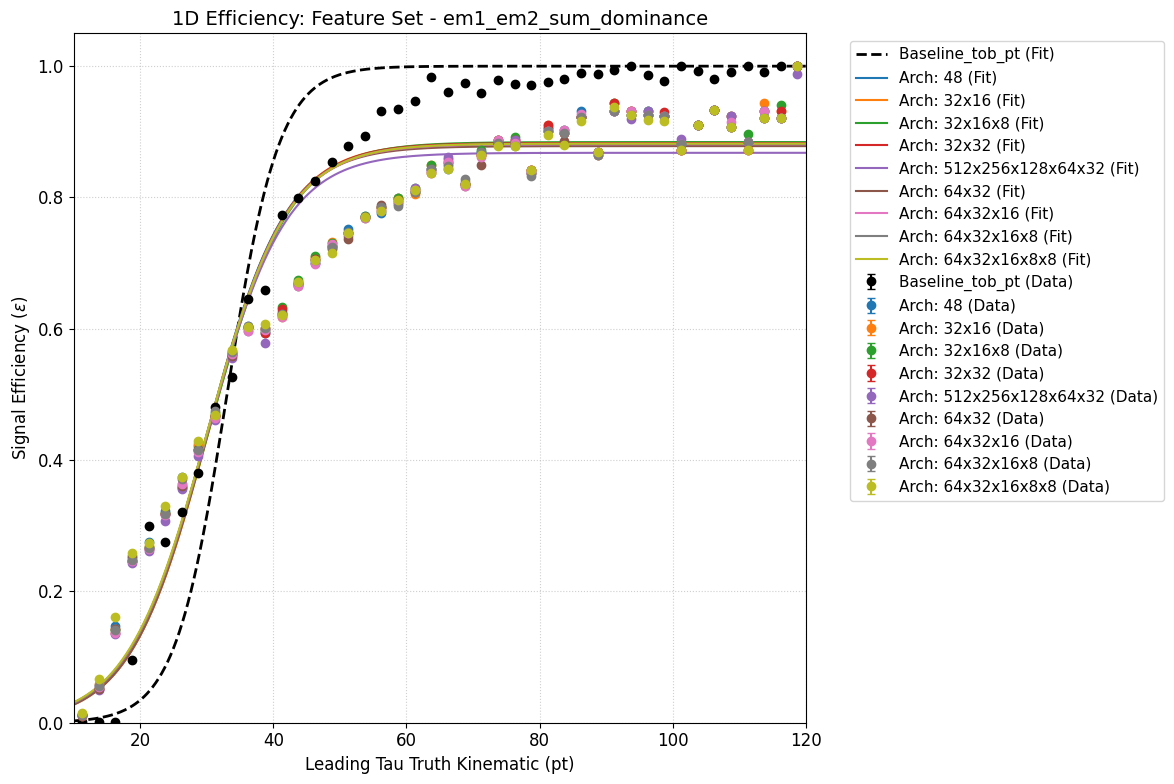

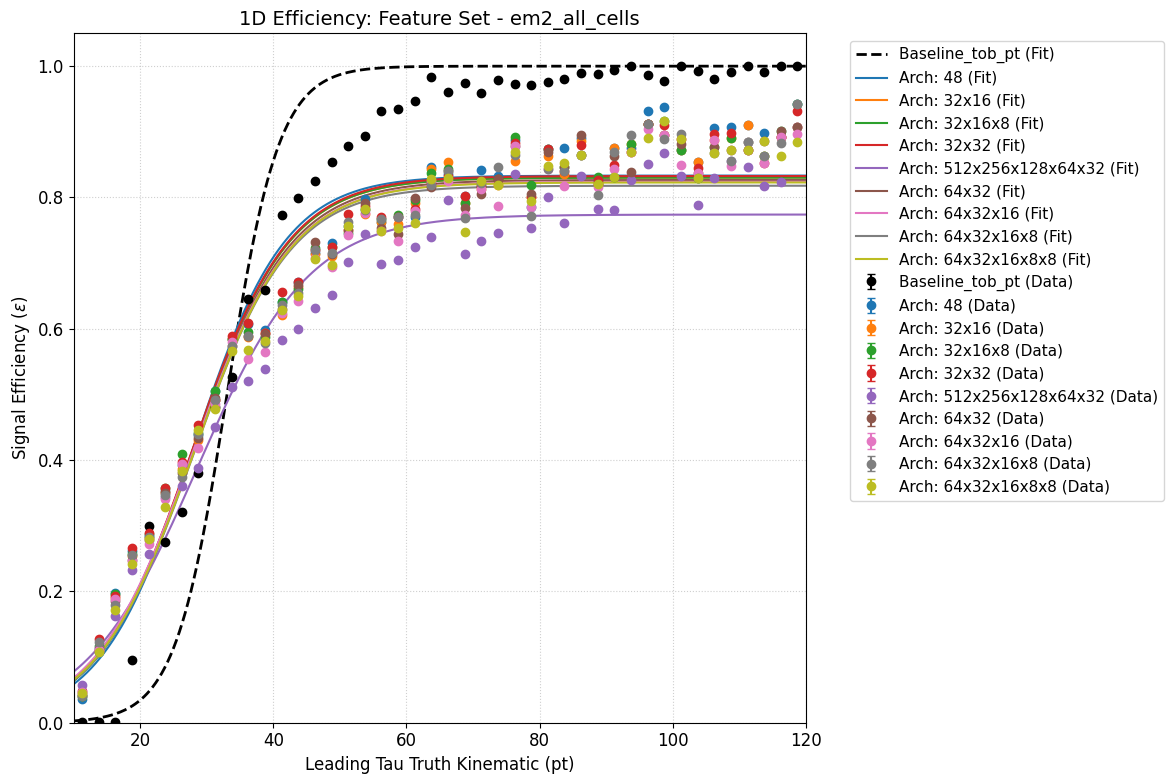

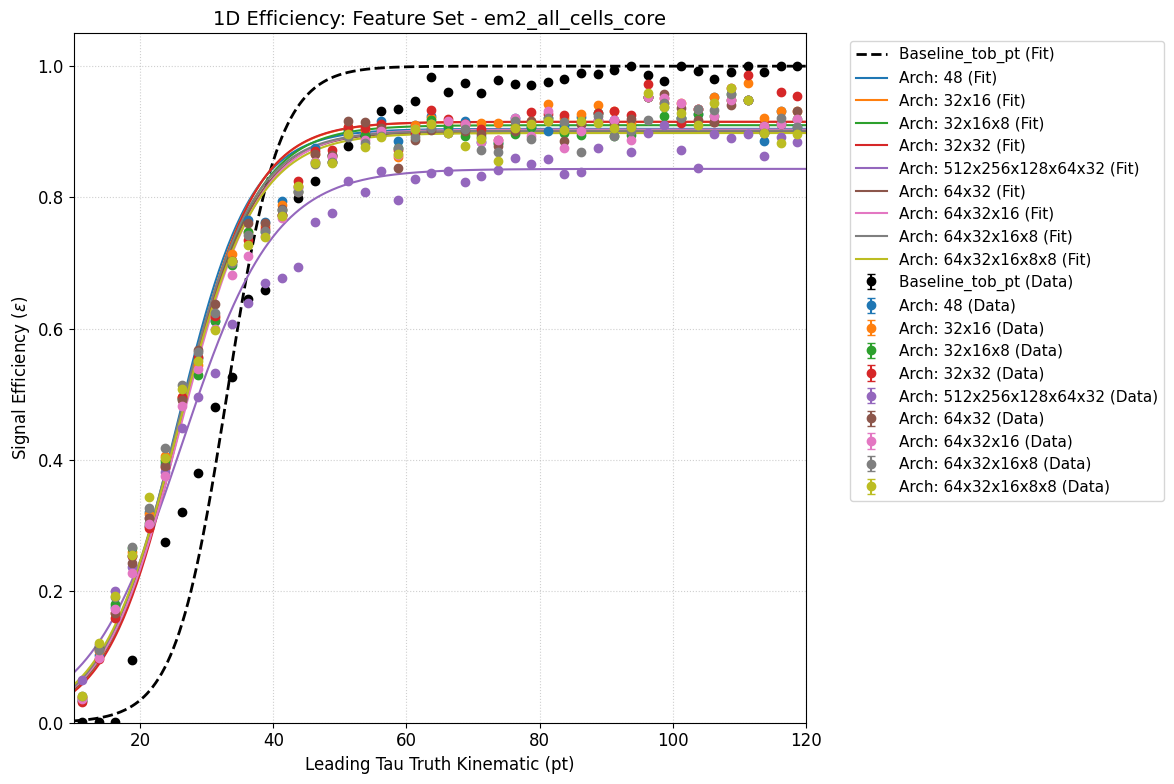

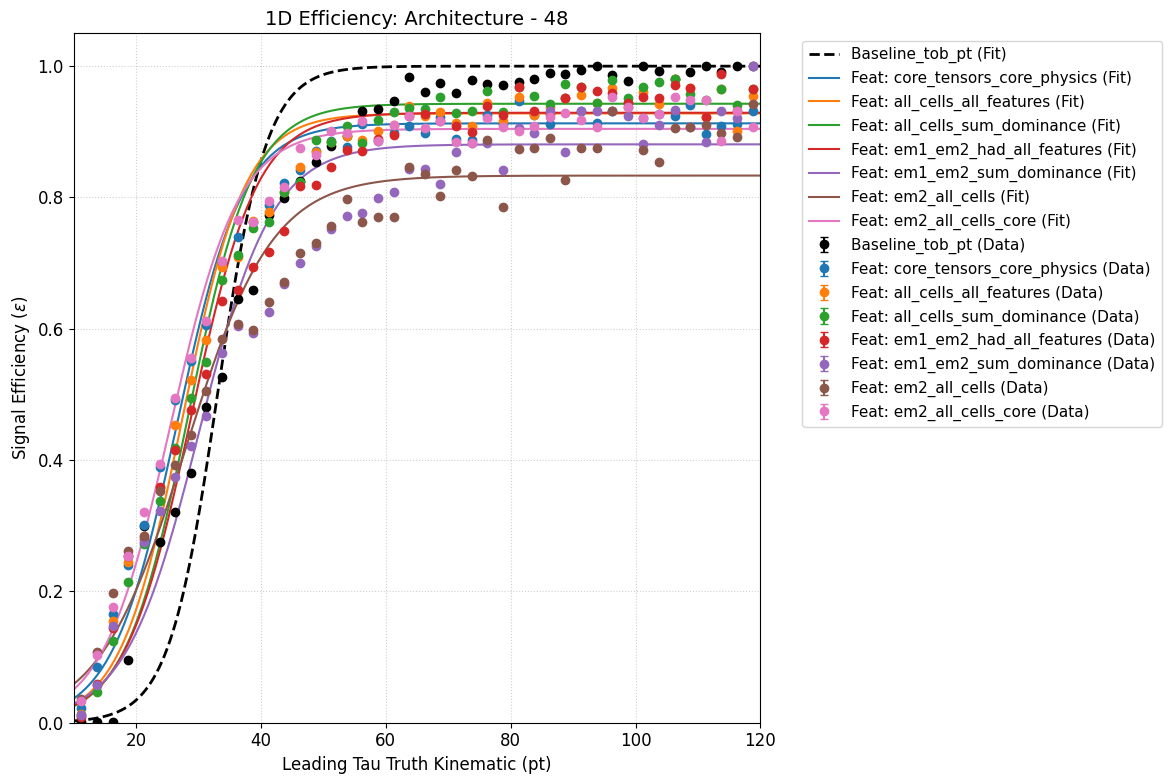

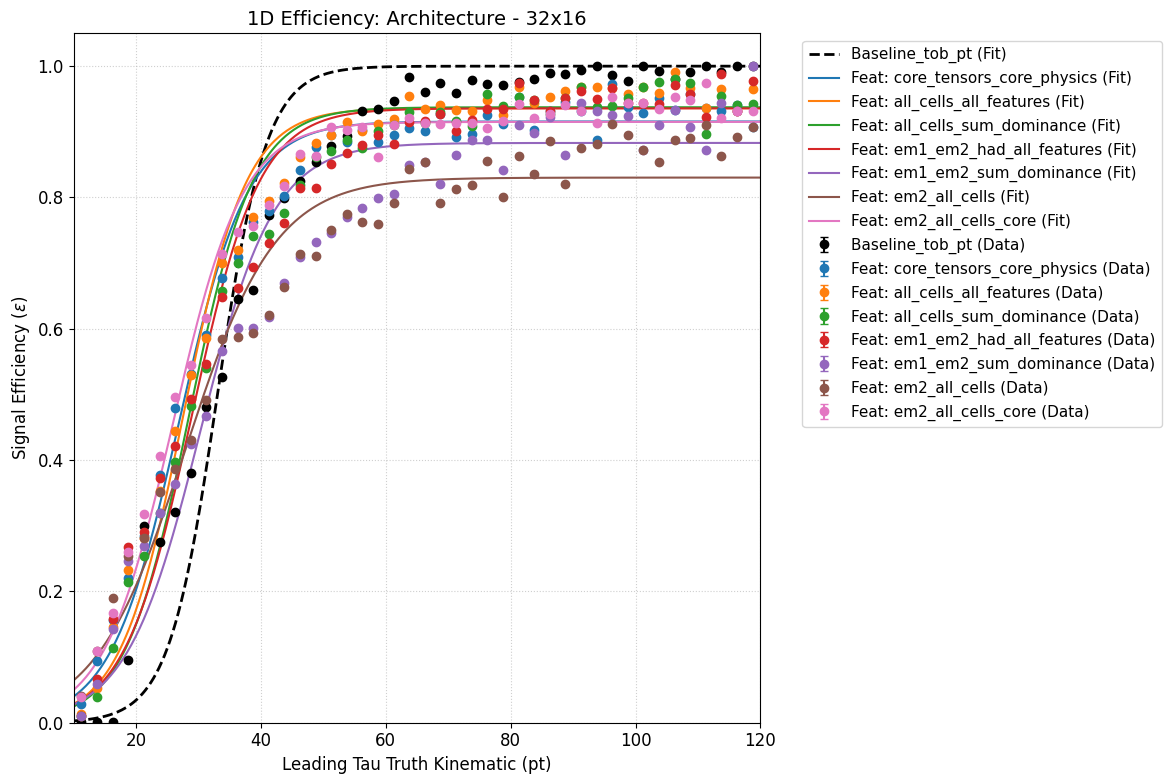

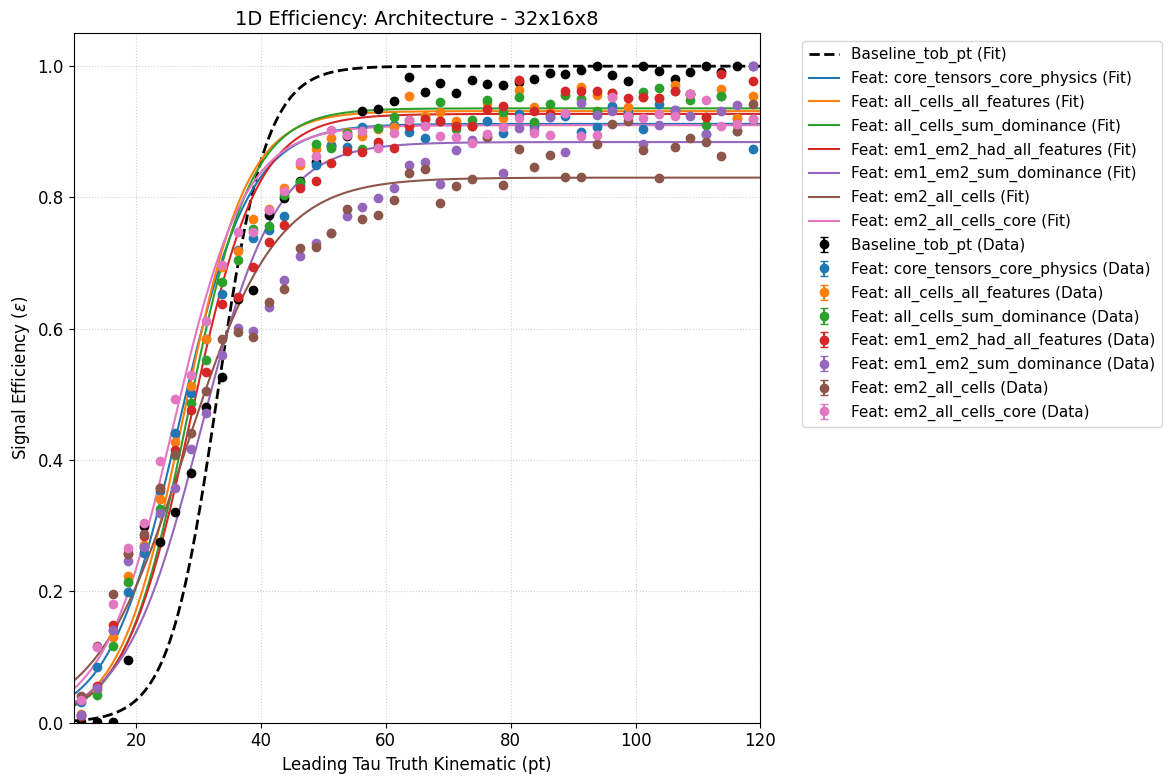

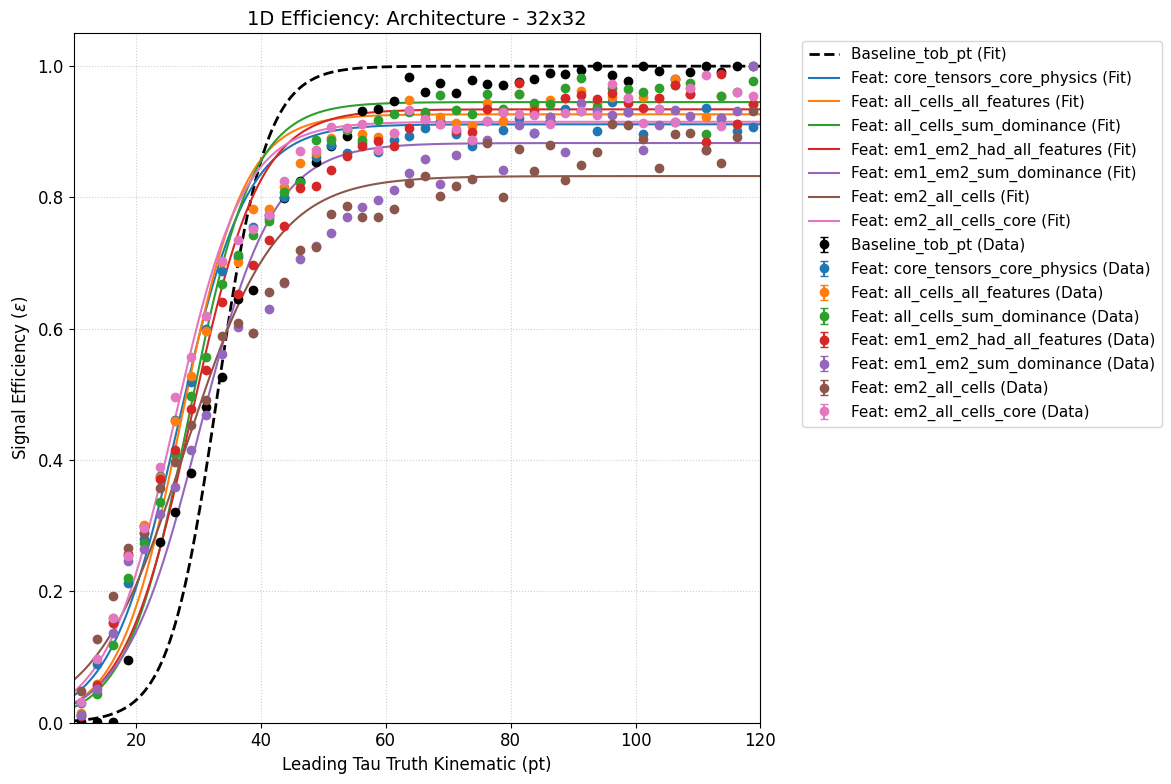

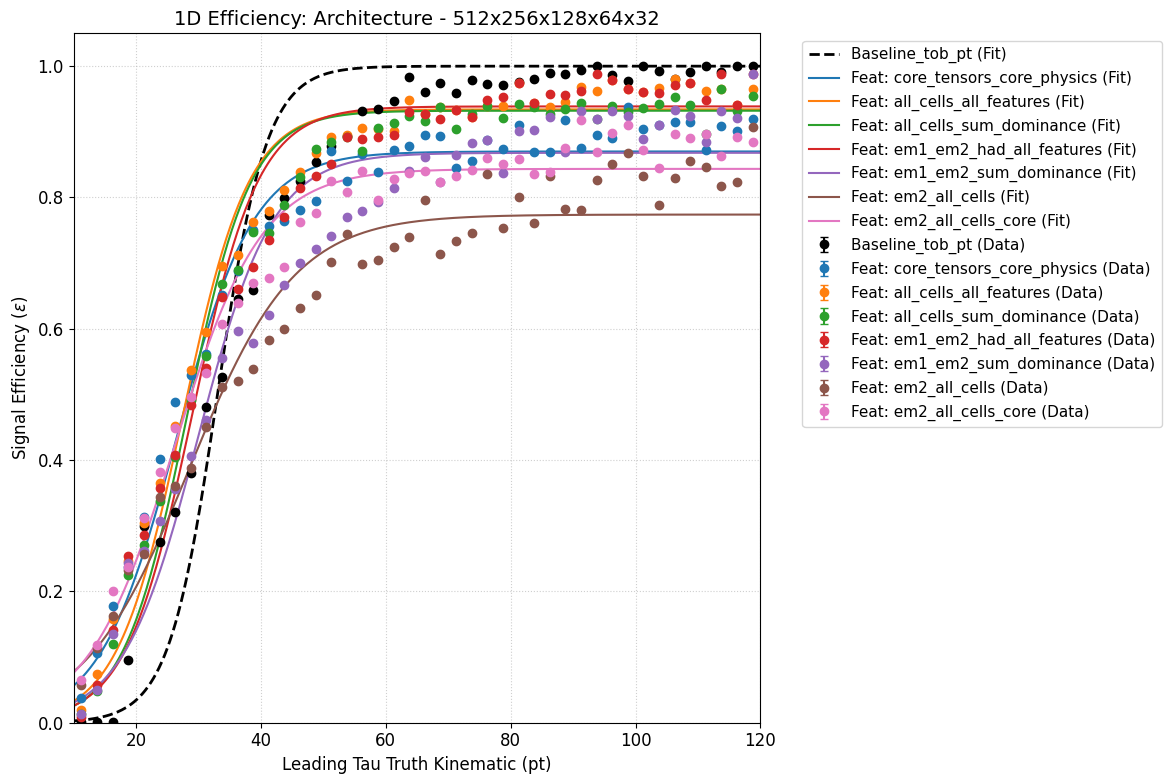

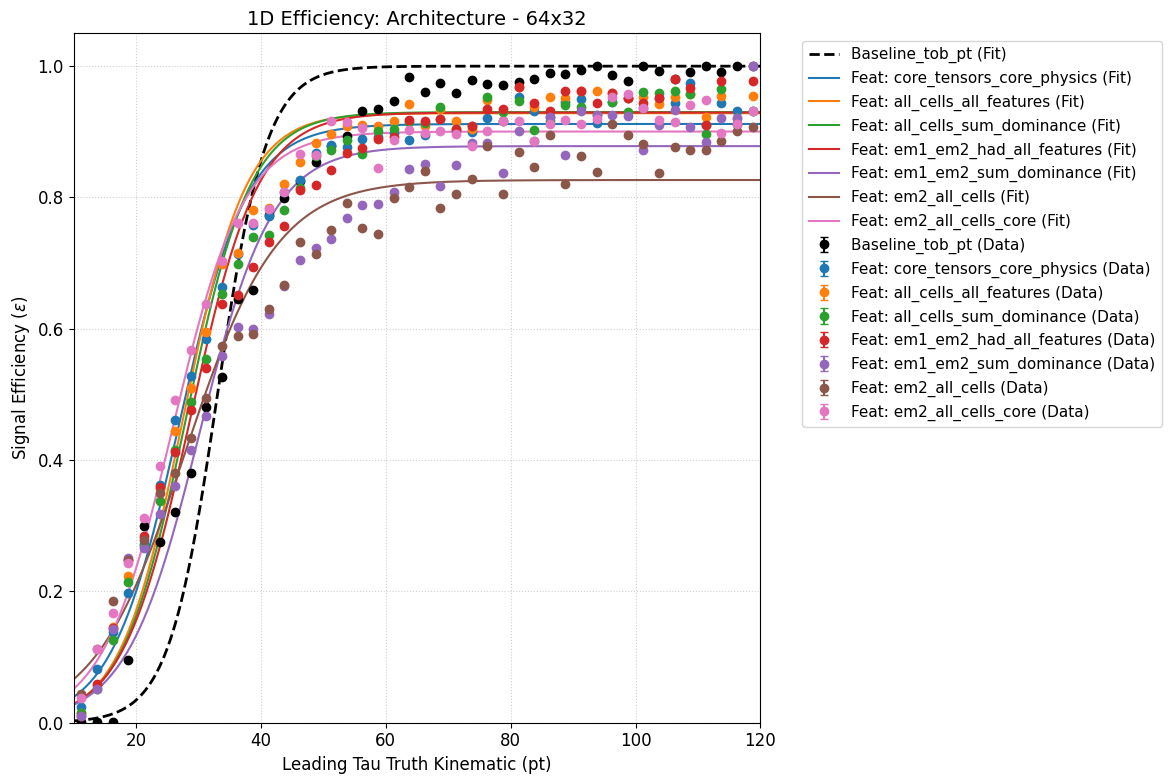

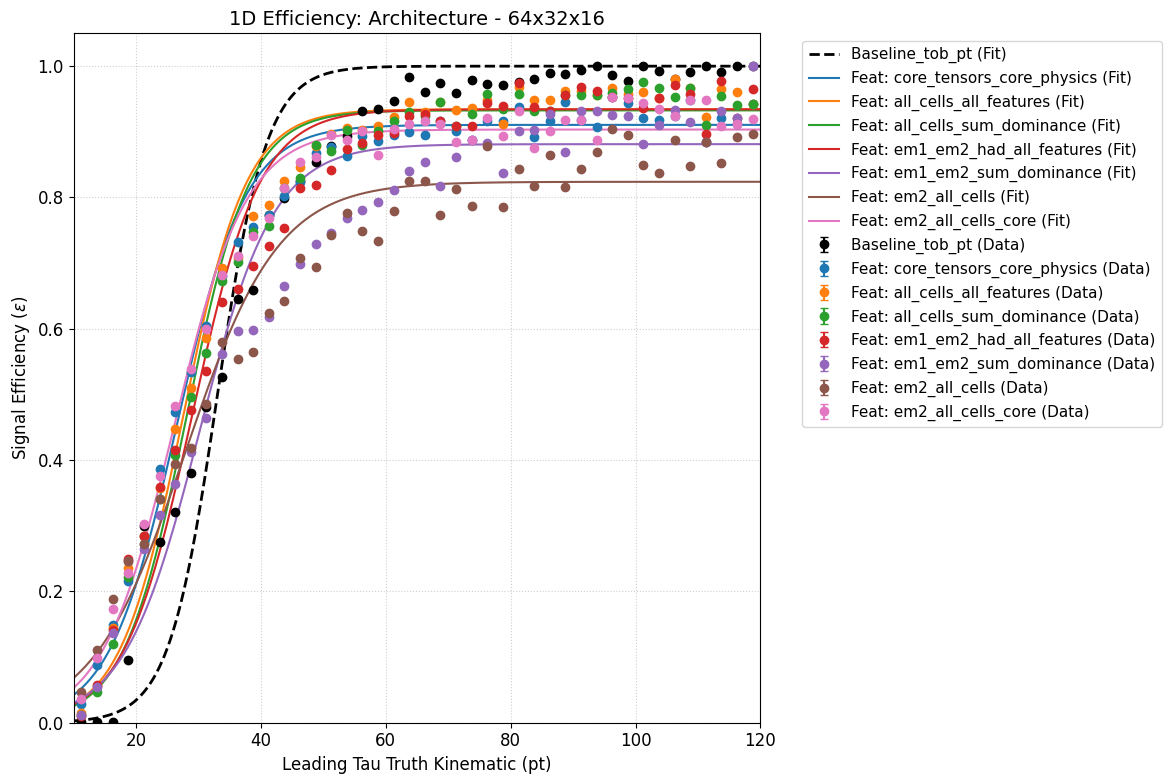

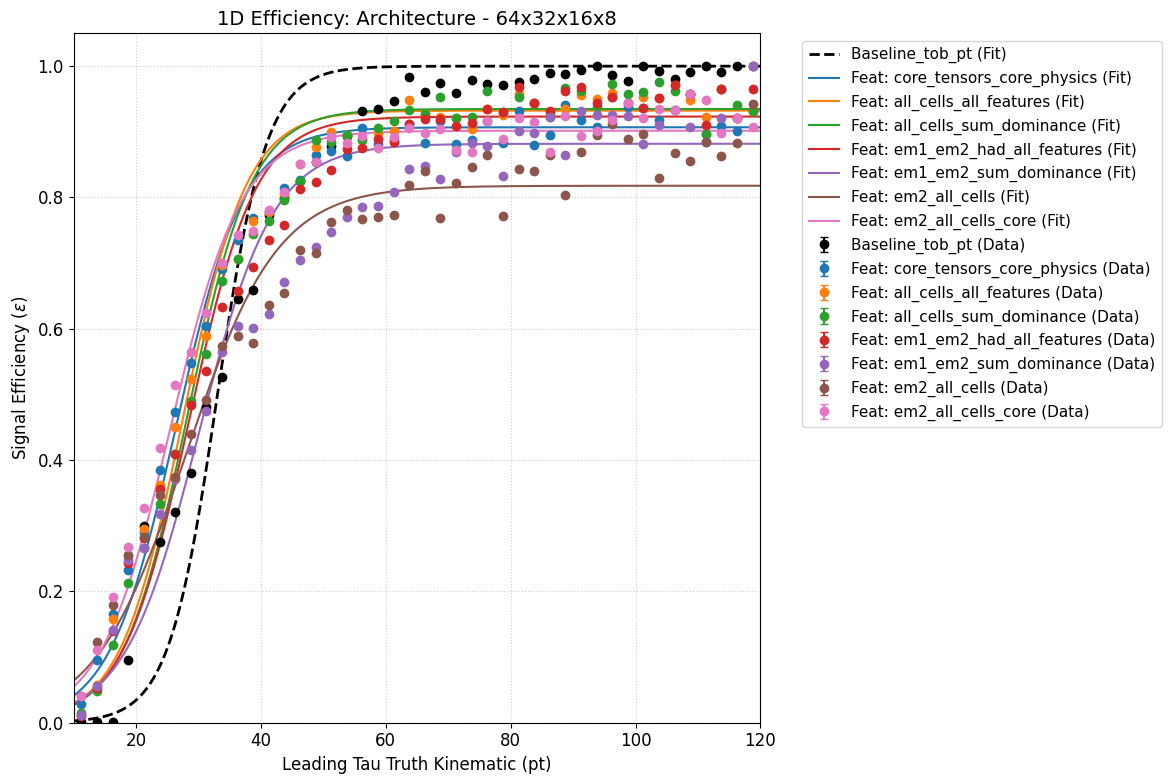

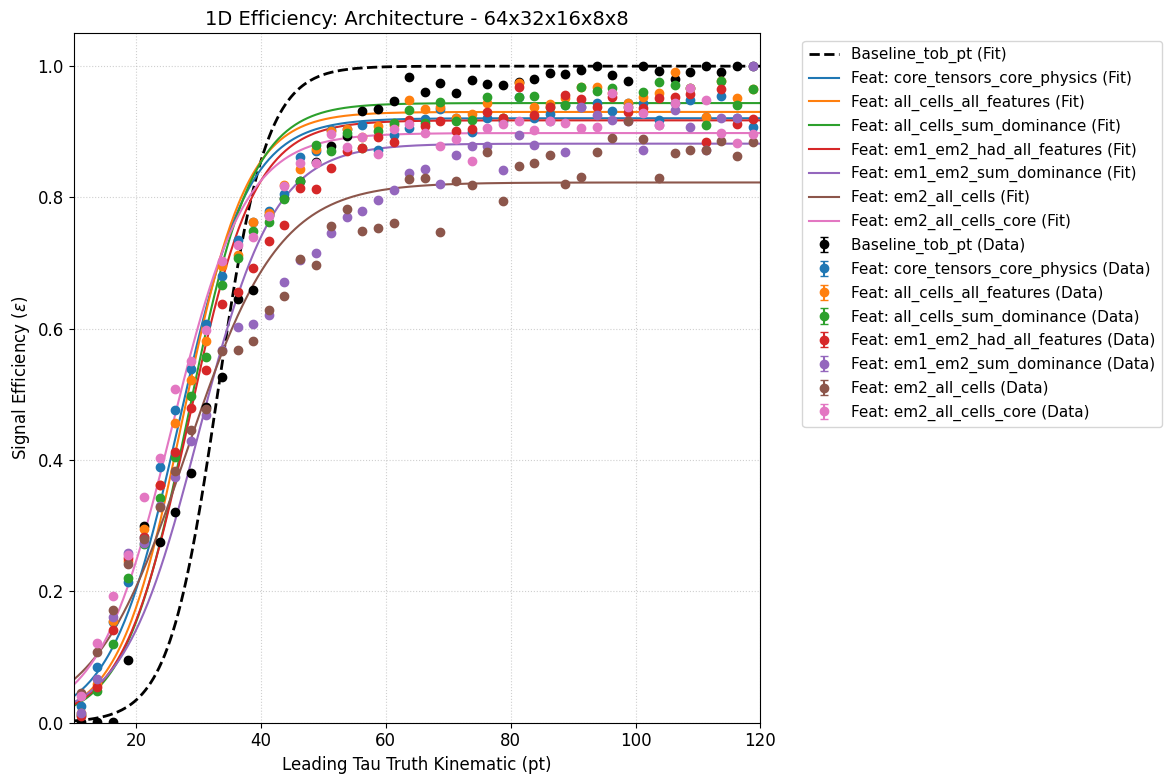

In [12]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

def fermi_dirac(x, midpoint, slope, plateau):
    return plateau / (1.0 + np.exp(-np.clip(slope * (x - midpoint), -500, 500)))

x_vals = np.linspace(10, 120, 500)

architectures = [
    '48', '32x16', '32x16x8', '32x32', '512x256x128x64x32', 
    '64x32', '64x32x16', '64x32x16x8', '64x32x16x8x8'
]

features = [
    'core_tensors_core_physics',
    'em0_dominance_em0_sparsity_em0_sum_em1_dominance_em1_sparsity_em1_sum_em2_3x3_dominance_em2_3x3_sparsity_em2_3x3_sum_em3_dominance_em3_sparsity_em3_sum_had_dominance_had_sparsity_had_sum',
    'em0_dominance_em0_sum_em1_dominance_em1_sum_em2_3x3_dominance_em2_3x3_sum_em3_dominance_em3_sum_had_dominance_had_sum',
    'em1_dominance_em1_sparsity_em1_sum_em2_3x3_dominance_em2_3x3_sparsity_em2_3x3_sum_had_dominance_had_sparsity_had_sum',
    'em1_dominance_em1_sum_em2_3x3_dominance_em2_3x3_sum',
    'em2_all_cells',
    'em2_all_cells_core_tensors_core_physics'
]

feature_aliases = {
    features[0]: 'core_tensors_core_physics',
    features[1]: 'all_cells_all_features',
    features[2]: 'all_cells_sum_dominance',
    features[3]: 'em1_em2_had_all_features',
    features[4]: 'em1_em2_sum_dominance',
    features[5]: 'em2_all_cells',
    features[6]: 'em2_all_cells_core'
}

def plot_experiments(name, experiment_names, title, custom_labels=None):
    if custom_labels is None:
        custom_labels = {}
        
    plt.figure(figsize=(12, 8))
    
    baseline = df_experiments[df_experiments['experiment_name'] == 'Baseline_tob_pt']
    if not baseline.empty:
        b_row = baseline.iloc[0]
        m_path = os.path.join(b_row['path'], "metrics.json")
        if os.path.exists(m_path):
            with open(m_path, 'r') as f:
                metrics = json.load(f)
            toc_data = metrics["turn_on_curve"]
            eval_bins = np.array(toc_data.get("bins", toc_data.get("pt_bins")))
            bin_centers = (eval_bins[:-1] + eval_bins[1:]) / 2.0
            binned_effs = toc_data["binned_efficiencies"]
            binned_errs = toc_data.get("binned_errors", np.zeros_like(binned_effs))
            
            plt.errorbar(bin_centers, binned_effs, yerr=binned_errs, fmt='o', 
                         capsize=3, color='black', label='Baseline_tob_pt (Data)')
            
            y_vals = fermi_dirac(x_vals, b_row['fd_midpoint'], b_row['fd_slope'], b_row['fd_plateau'])
            plt.plot(x_vals, y_vals, label='Baseline_tob_pt (Fit)', linestyle='--', color='black', linewidth=2)

    for exp in experiment_names:
        row = df_experiments[df_experiments['experiment_name'] == exp]
        if not row.empty:
            r = row.iloc[0]
            m_path = os.path.join(r['path'], "metrics.json")
            if os.path.exists(m_path):
                with open(m_path, 'r') as f:
                    metrics = json.load(f)
                toc_data = metrics["turn_on_curve"]
                eval_bins = np.array(toc_data.get("bins", toc_data.get("pt_bins")))
                bin_centers = (eval_bins[:-1] + eval_bins[1:]) / 2.0
                binned_effs = toc_data["binned_efficiencies"]
                binned_errs = toc_data.get("binned_errors", np.zeros_like(binned_effs))
                
                clean_label = custom_labels.get(exp, exp)
                
                line = plt.errorbar(bin_centers, binned_effs, yerr=binned_errs, fmt='o', 
                                    capsize=3, label=f"{clean_label} (Data)")
                
                y_vals = fermi_dirac(x_vals, r['fd_midpoint'], r['fd_slope'], r['fd_plateau'])
                plt.plot(x_vals, y_vals, label=f"{clean_label} (Fit)", color=line[0].get_color())
    
    plt.title(title)
    plt.xlabel('Leading Tau Truth Kinematic (pt)')
    plt.ylabel(r'Signal Efficiency ($\epsilon$)')
    plt.xlim(10, 120)
    plt.ylim(0.0, 1.05)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(name + '.pdf', format='pdf', bbox_inches='tight')
    plt.show()

for f in features:
    exp_names = [f'TauNet_lr0.001_bs256_arch{arch}_{f}' for arch in architectures]
    f_alias = feature_aliases[f]
    custom_labels = {f'TauNet_lr0.001_bs256_arch{arch}_{f}': f"Arch: {arch}" for arch in architectures}
    plot_experiments(f"batch_3_feature_{f_alias}", exp_names, f"1D Efficiency: Feature Set - {f_alias}", custom_labels)

for arch in architectures:
    exp_names = [f'TauNet_lr0.001_bs256_arch{arch}_{f}' for f in features]
    custom_labels = {f'TauNet_lr0.001_bs256_arch{arch}_{f}': f"Feat: {feature_aliases[f]}" for f in features}
    plot_experiments(f"batch_3_arch_{arch}", exp_names, f"1D Efficiency: Architecture - {arch}", custom_labels)

# DIFFERENT DISTANCE VARIANTS ANLAYSIS

C:\Users\Dror\AppData\Local\Temp\ipykernel_33816\1763294047.py:80: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


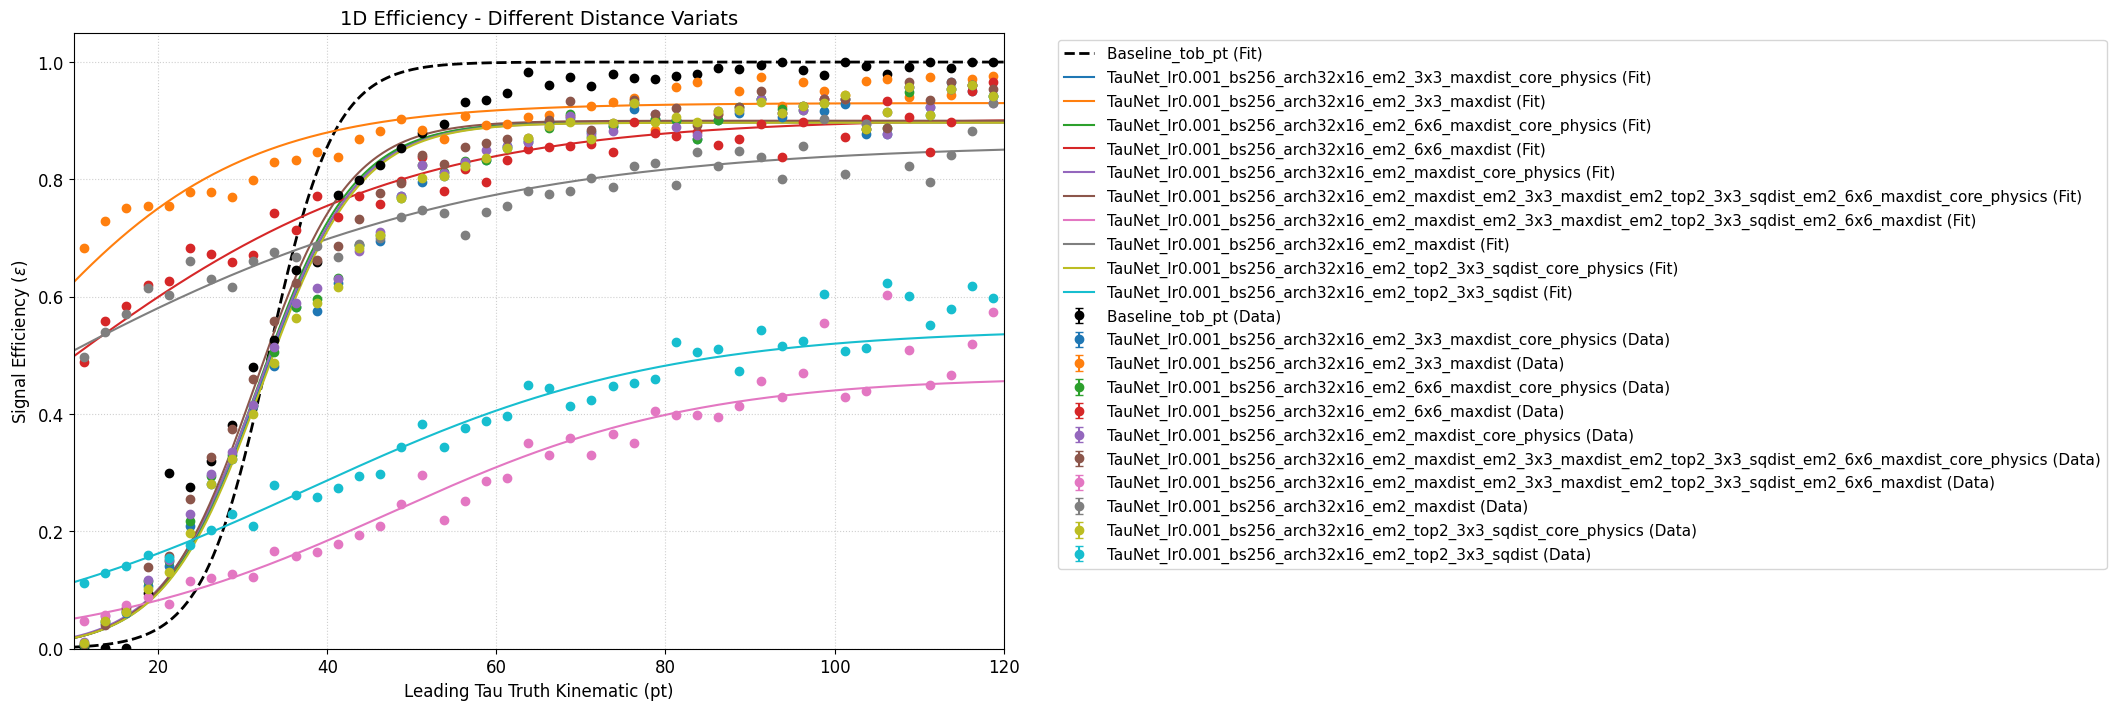

In [7]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

exp_names = [
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist_core_physics",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_6x6_maxdist_core_physics",
"TauNet_lr0.001_bs256_arch32x16_em2_6x6_maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_maxdist_core_physics",
"TauNet_lr0.001_bs256_arch32x16_em2_maxdist_em2_3x3_maxdist_em2_top2_3x3_sqdist_em2_6x6_maxdist_core_physics",
"TauNet_lr0.001_bs256_arch32x16_em2_maxdist_em2_3x3_maxdist_em2_top2_3x3_sqdist_em2_6x6_maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_top2_3x3_sqdist_core_physics",
"TauNet_lr0.001_bs256_arch32x16_em2_top2_3x3_sqdist",
]



def fermi_dirac(x, midpoint, slope, plateau):
    return plateau / (1.0 + np.exp(-np.clip(slope * (x - midpoint), -500, 500)))

x_vals = np.linspace(10, 120, 500)

def plot_experiments(name, experiment_names, title, custom_labels=None):
    if custom_labels is None:
        custom_labels = {}
        
    plt.figure(figsize=(12, 8))
    
    baseline = df_experiments[df_experiments['experiment_name'] == 'Baseline_tob_pt']
    if not baseline.empty:
        b_row = baseline.iloc[0]
        m_path = os.path.join(b_row['path'], "metrics.json")
        if os.path.exists(m_path):
            with open(m_path, 'r') as f:
                metrics = json.load(f)
            toc_data = metrics["turn_on_curve"]
            eval_bins = np.array(toc_data.get("bins", toc_data.get("pt_bins")))
            bin_centers = (eval_bins[:-1] + eval_bins[1:]) / 2.0
            binned_effs = toc_data["binned_efficiencies"]
            binned_errs = toc_data.get("binned_errors", np.zeros_like(binned_effs))
            
            plt.errorbar(bin_centers, binned_effs, yerr=binned_errs, fmt='o', 
                         capsize=3, color='black', label='Baseline_tob_pt (Data)')
            
            y_vals = fermi_dirac(x_vals, b_row['fd_midpoint'], b_row['fd_slope'], b_row['fd_plateau'])
            plt.plot(x_vals, y_vals, label='Baseline_tob_pt (Fit)', linestyle='--', color='black', linewidth=2)

    for exp in experiment_names:
        row = df_experiments[df_experiments['experiment_name'] == exp]
        if not row.empty:
            r = row.iloc[0]
            m_path = os.path.join(r['path'], "metrics.json")
            if os.path.exists(m_path):
                with open(m_path, 'r') as f:
                    metrics = json.load(f)
                toc_data = metrics["turn_on_curve"]
                eval_bins = np.array(toc_data.get("bins", toc_data.get("pt_bins")))
                bin_centers = (eval_bins[:-1] + eval_bins[1:]) / 2.0
                binned_effs = toc_data["binned_efficiencies"]
                binned_errs = toc_data.get("binned_errors", np.zeros_like(binned_effs))
                
                clean_label = custom_labels.get(exp, exp)
                
                line = plt.errorbar(bin_centers, binned_effs, yerr=binned_errs, fmt='o', 
                                    capsize=3, label=f"{clean_label} (Data)")
                
                y_vals = fermi_dirac(x_vals, r['fd_midpoint'], r['fd_slope'], r['fd_plateau'])
                plt.plot(x_vals, y_vals, label=f"{clean_label} (Fit)", color=line[0].get_color())
    
    plt.title(title)
    plt.xlabel('Leading Tau Truth Kinematic (pt)')
    plt.ylabel(r'Signal Efficiency ($\epsilon$)')
    plt.xlim(10, 120)
    plt.ylim(0.0, 1.05)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(name + '.pdf', format='pdf', bbox_inches='tight')
    plt.show()

plot_experiments("1D Efficiency - Different Distance Variats", exp_names, "1D Efficiency - Different Distance Variats")

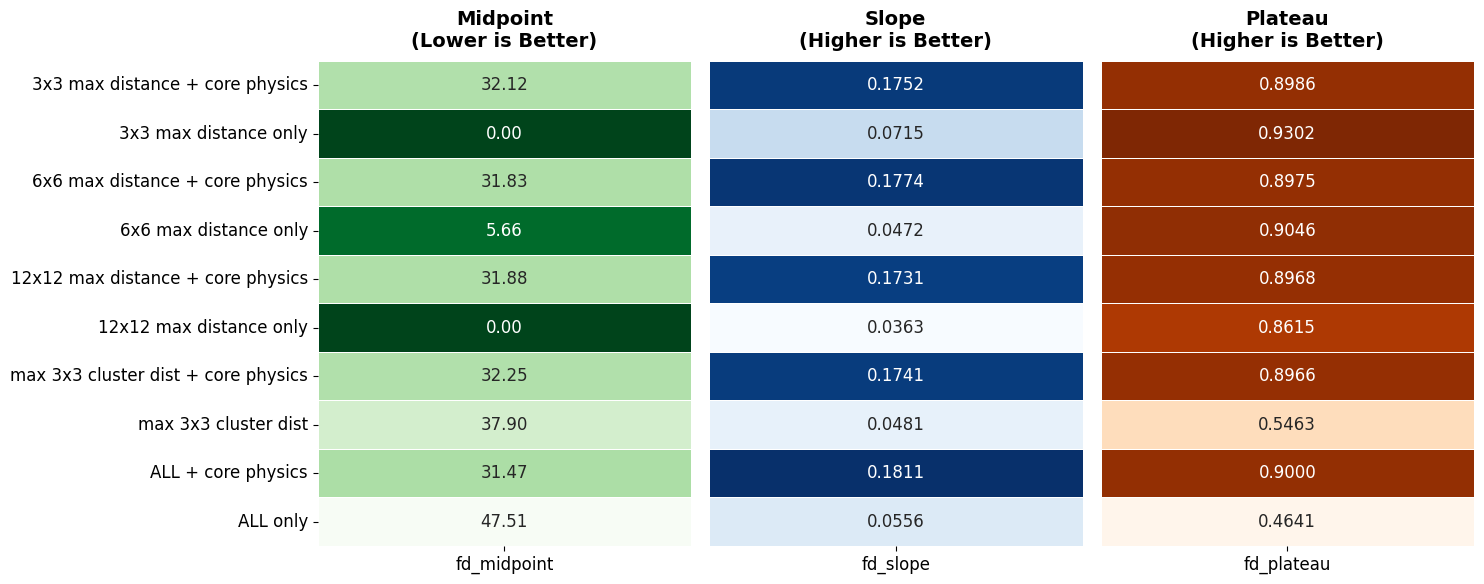

In [18]:
# HEAT MAP PRETTY PRINT FOR LATEX


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



name_mapping = {
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist_core_physics": "3x3 max distance + core physics",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist": "3x3 max distance only",
"TauNet_lr0.001_bs256_arch32x16_em2_6x6_maxdist_core_physics": "6x6 max distance + core physics",
"TauNet_lr0.001_bs256_arch32x16_em2_6x6_maxdist": "6x6 max distance only",
"TauNet_lr0.001_bs256_arch32x16_em2_maxdist_core_physics": "12x12 max distance + core physics",
"TauNet_lr0.001_bs256_arch32x16_em2_maxdist_em2_3x3_maxdist_em2_top2_3x3_sqdist_em2_6x6_maxdist_core_physics": "ALL + core physics",
"TauNet_lr0.001_bs256_arch32x16_em2_maxdist_em2_3x3_maxdist_em2_top2_3x3_sqdist_em2_6x6_maxdist": "ALL only",
"TauNet_lr0.001_bs256_arch32x16_em2_maxdist": "12x12 max distance only",
"TauNet_lr0.001_bs256_arch32x16_em2_top2_3x3_sqdist_core_physics": "max 3x3 cluster dist + core physics",
"TauNet_lr0.001_bs256_arch32x16_em2_top2_3x3_sqdist": "max 3x3 cluster dist",
}

# Define the order we want them to appear in the heatmap (top to bottom)
ordered_index = [
"3x3 max distance + core physics",
"3x3 max distance only",
"6x6 max distance + core physics",
"6x6 max distance only",
"12x12 max distance + core physics",
"12x12 max distance only",
"max 3x3 cluster dist + core physics",
"max 3x3 cluster dist",
"ALL + core physics",
"ALL only",
]

# Apply mapping and set as index
df_heat = df_experiments.copy()
df_heat['Clean_Name'] = df_heat['experiment_name'].map(name_mapping)

# Drop any rows that didn't match the map (optional) and set index
df_heat = df_heat.dropna(subset=['Clean_Name']).set_index('Clean_Name')
df_heat = df_heat.reindex(ordered_index)

# 2. Plotting the 1x3 Heatmap
fig, axes = plt.subplots(1, 3, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1, 1]})

# Midpoint Heatmap (Lower is better, so we reverse the colormap: _r)
sns.heatmap(df_heat[['fd_midpoint']], annot=True, fmt=".2f", cmap="Greens_r", 
            ax=axes[0], cbar=False, linewidths=0.5, linecolor='white')
axes[0].set_title("Midpoint\n(Lower is Better)", pad=10, weight='bold')
axes[0].set_ylabel("") 

# Slope Heatmap (Higher is better)
sns.heatmap(df_heat[['fd_slope']], annot=True, fmt=".4f", cmap="Blues", 
            ax=axes[1], cbar=False, linewidths=0.5, linecolor='white')
axes[1].set_title("Slope\n(Higher is Better)", pad=10, weight='bold')
axes[1].set_ylabel("")
axes[1].set_yticks([]) # Hide y-axis labels for the middle plot so it's not cluttered

# Plateau Heatmap (Higher is better)
sns.heatmap(df_heat[['fd_plateau']], annot=True, fmt=".4f", cmap="Oranges", 
            ax=axes[2], cbar=False, linewidths=0.5, linecolor='white')
axes[2].set_title("Plateau\n(Higher is Better)", pad=10, weight='bold')
axes[2].set_ylabel("")
axes[2].set_yticks([]) # Hide y-axis labels for the right plot

# Adjust layout and save
fig.tight_layout()
fig.savefig('DESCRIBE HEATMAP HERE.pdf', format='pdf', bbox_inches='tight')
plt.show()

# SIMPLE VECTORS ANALYSIS

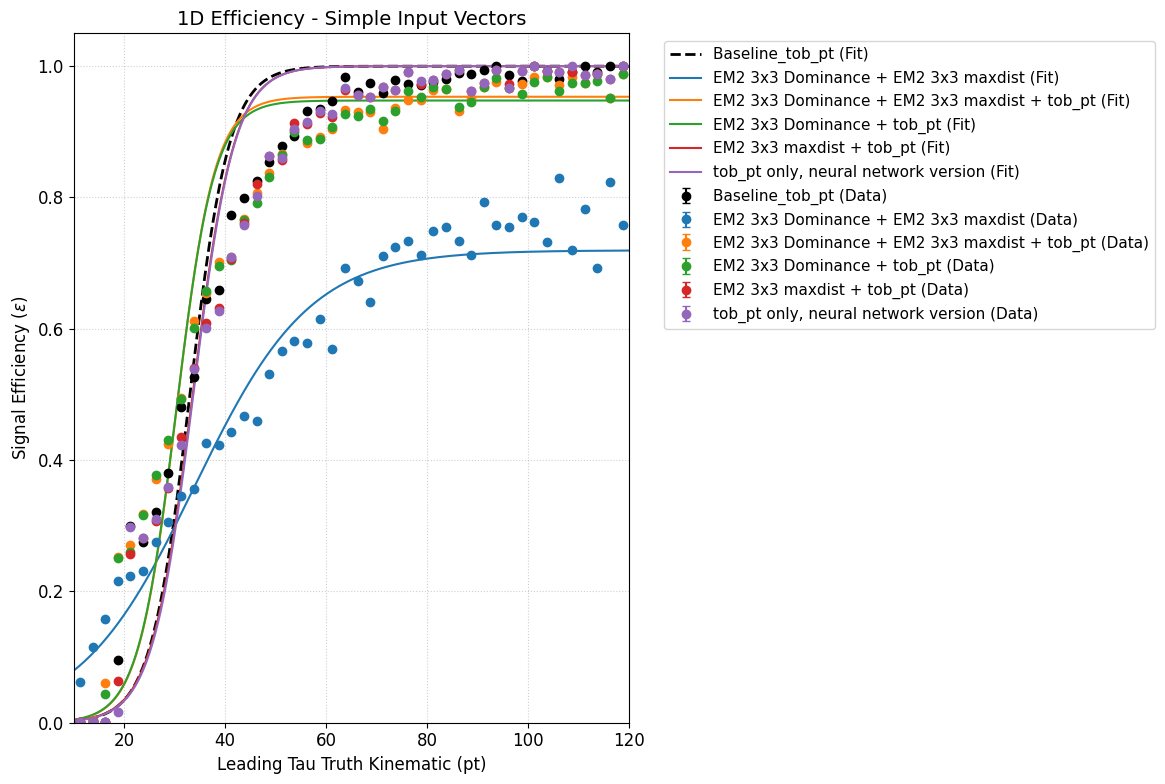

In [9]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

exp_names = [
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_tob_pt_only",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist_tob_pt_only",
"TauNet_lr0.001_bs256_arch32x16_tob_pt_only",
]

name_mapping = {
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist": "EM2 3x3 Dominance + EM2 3x3 maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only": "EM2 3x3 Dominance + EM2 3x3 maxdist + tob_pt",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_tob_pt_only": "EM2 3x3 Dominance + tob_pt",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist_tob_pt_only": "EM2 3x3 maxdist + tob_pt",
"TauNet_lr0.001_bs256_arch32x16_tob_pt_only": "tob_pt only, neural network version",
}


def fermi_dirac(x, midpoint, slope, plateau):
    return plateau / (1.0 + np.exp(-np.clip(slope * (x - midpoint), -500, 500)))

x_vals = np.linspace(10, 120, 500)

def plot_experiments(name, experiment_names, title, custom_labels=None):
    if custom_labels is None:
        custom_labels = {}
        
    plt.figure(figsize=(12, 8))
    
    baseline = df_experiments[df_experiments['experiment_name'] == 'Baseline_tob_pt']
    if not baseline.empty:
        b_row = baseline.iloc[0]
        m_path = os.path.join(b_row['path'], "metrics.json")
        if os.path.exists(m_path):
            with open(m_path, 'r') as f:
                metrics = json.load(f)
            toc_data = metrics["turn_on_curve"]
            eval_bins = np.array(toc_data.get("bins", toc_data.get("pt_bins")))
            bin_centers = (eval_bins[:-1] + eval_bins[1:]) / 2.0
            binned_effs = toc_data["binned_efficiencies"]
            binned_errs = toc_data.get("binned_errors", np.zeros_like(binned_effs))
            
            plt.errorbar(bin_centers, binned_effs, yerr=binned_errs, fmt='o', 
                         capsize=3, color='black', label='Baseline_tob_pt (Data)')
            
            y_vals = fermi_dirac(x_vals, b_row['fd_midpoint'], b_row['fd_slope'], b_row['fd_plateau'])
            plt.plot(x_vals, y_vals, label='Baseline_tob_pt (Fit)', linestyle='--', color='black', linewidth=2)

    for exp in experiment_names:
        row = df_experiments[df_experiments['experiment_name'] == exp]
        if not row.empty:
            r = row.iloc[0]
            m_path = os.path.join(r['path'], "metrics.json")
            if os.path.exists(m_path):
                with open(m_path, 'r') as f:
                    metrics = json.load(f)
                toc_data = metrics["turn_on_curve"]
                eval_bins = np.array(toc_data.get("bins", toc_data.get("pt_bins")))
                bin_centers = (eval_bins[:-1] + eval_bins[1:]) / 2.0
                binned_effs = toc_data["binned_efficiencies"]
                binned_errs = toc_data.get("binned_errors", np.zeros_like(binned_effs))
                
                clean_label = custom_labels.get(exp, exp)
                clean_label = name_mapping[exp]              
                line = plt.errorbar(bin_centers, binned_effs, yerr=binned_errs, fmt='o', 
                                    capsize=3, label=f"{clean_label} (Data)")
                
                y_vals = fermi_dirac(x_vals, r['fd_midpoint'], r['fd_slope'], r['fd_plateau'])
                plt.plot(x_vals, y_vals, label=f"{clean_label} (Fit)", color=line[0].get_color())
    
    plt.title(title)
    plt.xlabel('Leading Tau Truth Kinematic (pt)')
    plt.ylabel(r'Signal Efficiency ($\epsilon$)')
    plt.xlim(10, 120)
    plt.ylim(0.0, 1.05)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
    plt.savefig(name + '.pdf', format='pdf', bbox_inches='tight')
    plt.show()

plot_experiments("1D Efficiency - Simple Input Vectors", exp_names, "1D Efficiency - Simple Input Vectors")

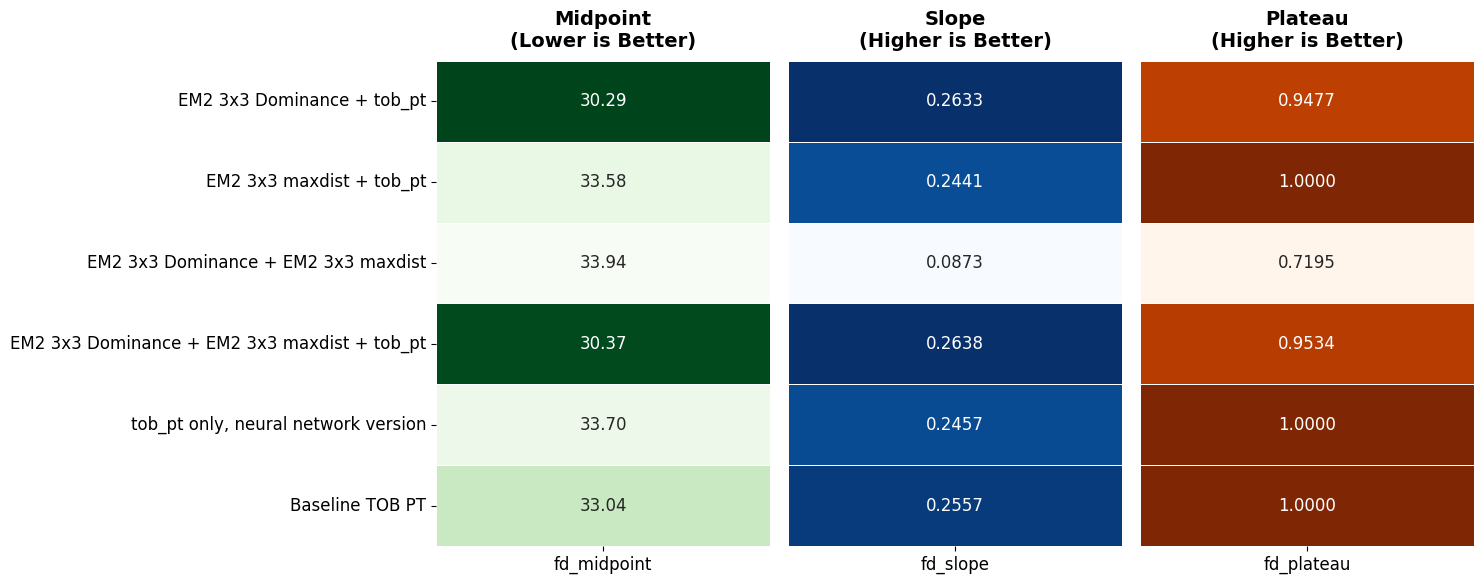

In [10]:
# HEAT MAP PRETTY PRINT FOR LATEX


import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt



name_mapping = {
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist": "EM2 3x3 Dominance + EM2 3x3 maxdist",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_em2_3x3_maxdist_tob_pt_only": "EM2 3x3 Dominance + EM2 3x3 maxdist + tob_pt",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_dominance_tob_pt_only": "EM2 3x3 Dominance + tob_pt",
"TauNet_lr0.001_bs256_arch32x16_em2_3x3_maxdist_tob_pt_only": "EM2 3x3 maxdist + tob_pt",
"TauNet_lr0.001_bs256_arch32x16_tob_pt_only": "tob_pt only, neural network version",
"Baseline_tob_pt": "Baseline TOB PT",
}

# Define the order we want them to appear in the heatmap (top to bottom)
ordered_index = [
"EM2 3x3 Dominance + tob_pt",
"EM2 3x3 maxdist + tob_pt",
"EM2 3x3 Dominance + EM2 3x3 maxdist",
"EM2 3x3 Dominance + EM2 3x3 maxdist + tob_pt",
"tob_pt only, neural network version",
"Baseline TOB PT",
]

# Apply mapping and set as index
df_heat = df_experiments.copy()
df_heat['Clean_Name'] = df_heat['experiment_name'].map(name_mapping)

# Drop any rows that didn't match the map (optional) and set index
df_heat = df_heat.dropna(subset=['Clean_Name']).set_index('Clean_Name')
df_heat = df_heat.reindex(ordered_index)

# 2. Plotting the 1x3 Heatmap
fig, axes = plt.subplots(1, 3, figsize=(15, 6), gridspec_kw={'width_ratios': [1, 1, 1]})

# Midpoint Heatmap (Lower is better, so we reverse the colormap: _r)
sns.heatmap(df_heat[['fd_midpoint']], annot=True, fmt=".2f", cmap="Greens_r", 
            ax=axes[0], cbar=False, linewidths=0.5, linecolor='white')
axes[0].set_title("Midpoint\n(Lower is Better)", pad=10, weight='bold')
axes[0].set_ylabel("") 

# Slope Heatmap (Higher is better)
sns.heatmap(df_heat[['fd_slope']], annot=True, fmt=".4f", cmap="Blues", 
            ax=axes[1], cbar=False, linewidths=0.5, linecolor='white')
axes[1].set_title("Slope\n(Higher is Better)", pad=10, weight='bold')
axes[1].set_ylabel("")
axes[1].set_yticks([]) # Hide y-axis labels for the middle plot so it's not cluttered

# Plateau Heatmap (Higher is better)
sns.heatmap(df_heat[['fd_plateau']], annot=True, fmt=".4f", cmap="Oranges", 
            ax=axes[2], cbar=False, linewidths=0.5, linecolor='white')
axes[2].set_title("Plateau\n(Higher is Better)", pad=10, weight='bold')
axes[2].set_ylabel("")
axes[2].set_yticks([]) # Hide y-axis labels for the right plot

# Adjust layout and save
fig.tight_layout()
fig.savefig('DESCRIBE HEATMAP HERE.pdf', format='pdf', bbox_inches='tight')
plt.show()

# TEMP TEST

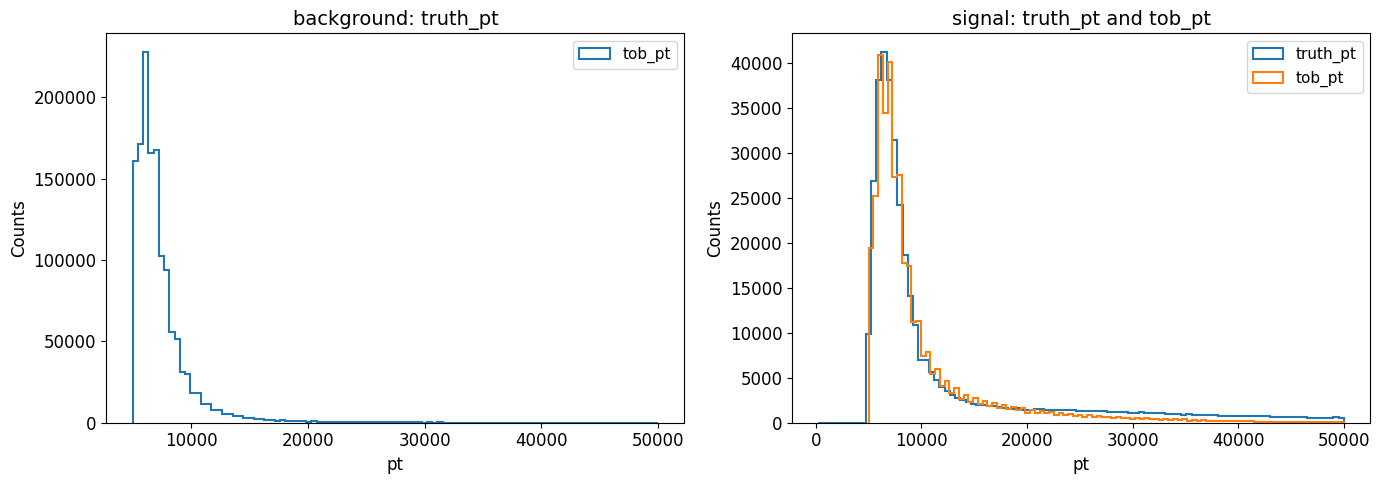

In [19]:
import matplotlib.pyplot as plt

dfbg = pd.read_csv(r"G:\My Drive\Documents\UNIVERSITY\TAU STUFF\lau tsu 9000\code\Refactored Codebase\Background\bkg_combined.csv")
df = pd.read_csv(r"G:\My Drive\Documents\UNIVERSITY\TAU STUFF\lau tsu 9000\code\Refactored Codebase\Signal\signal_combined.csv")

dfbg = dfbg[dfbg["truth_pt"].between(0,50000)]
dfbg = dfbg[dfbg["tob_pt"].between(0,50000)]
df = df[df["truth_pt"].between(0,50000)]
df = df[df["tob_pt"].between(0,50000)]

# Create a figure with 1 row and 2 columns
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Common bin settings (adjust the number or range of bins to fit your data)
bins = 100

# ==========================================
# LEFT PLOT: dfbg
# ==========================================

axes[0].hist(dfbg['tob_pt'], bins=bins, histtype='step', linewidth=1.5, label='tob_pt')

axes[0].set_title('background: truth_pt')
axes[0].set_xlabel('pt')
axes[0].set_ylabel('Counts')
axes[0].legend()

# ==========================================
# RIGHT PLOT: df
# ==========================================
axes[1].hist(df['truth_pt'], bins=bins, histtype='step', linewidth=1.5, label='truth_pt')
axes[1].hist(df['tob_pt'], bins=bins, histtype='step', linewidth=1.5, label='tob_pt')

axes[1].set_title('signal: truth_pt and tob_pt')
axes[1].set_xlabel('pt')
axes[1].set_ylabel('Counts')
axes[1].legend()

# Automatically adjust spacing between plots so labels don't overlap
plt.tight_layout()

# Display the plot
plt.show()